# **PHÂN TÍCH DỮ LIỆU: College Majors 2026 – Earnings, Debt, Jobs, AI**
Dành cho Google Colab | Tác giả: Oriana

**HƯỚNG DẪN SỬ DỤNG TRÊN GOOGLE COLAB:**
1. Upload file college_majors_2026.csv lên Colab (hoặc Google Drive)
2. Chạy từng cell theo thứ tự từ trên xuống dưới
3. File cleaned_college_majors.csv sẽ được tạo tự động để download


## **1. CÀI ĐẶT & IMPORT THƯ VIỆN**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Cài đặt style chung cho biểu đồ
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
sns.set_palette("muted")

print("Thư viện đã sẵn sàng.")

Thư viện đã sẵn sàng.


## **2. ĐỌC DỮ LIỆU**

In [3]:
FILE_PATH = "/college_majors_2026.csv"

df_raw = pd.read_csv(FILE_PATH, low_memory=False)

print(f"📂 Đã đọc file: {df_raw.shape[0]:,} dòng × {df_raw.shape[1]} cột")
print("\n📋 Danh sách cột:")
print(df_raw.columns.tolist())
print("\n🔍 5 dòng đầu:")
df_raw.head()

📂 Đã đọc file: 1,895 dòng × 72 cột

📋 Danh sách cột:
['program_id', 'unitid', 'opeid6', 'institution_name', 'institution_control', 'is_main_campus', 'institution_city', 'institution_state', 'institution_region', 'institution_latitude', 'institution_longitude', 'institution_is_hbcu', 'institution_admission_rate', 'institution_avg_sat', 'institution_undergrad_enrollment', 'institution_tuition_in_state_usd', 'institution_tuition_out_state_usd', 'cip_code_4digit', 'cip_title', 'cip_family_code', 'cip_family_title', 'credential_level', 'credential_name', 'distance_education', 'awards_year1', 'awards_year2', 'outcomes_shared_across_campuses', 'median_earnings_4yr_usd', 'earnings_cohort_size_4yr', 'national_median_earnings_4yr_usd', 'national_p25_earnings_4yr_usd', 'national_p75_earnings_4yr_usd', 'earnings_vs_national_pct', 'median_earnings_1yr_usd', 'earnings_cohort_size_1yr', 'median_earnings_5yr_usd', 'earnings_cohort_size_5yr', 'not_working_count_5yr', 'count_above_hs_threshold_5yr', 'co

,program_id,unitid,opeid6,institution_name,institution_control,is_main_campus,institution_city,institution_state,institution_region,institution_latitude,...,occupations_using_ai_software,ai_software_occupation_share,expert_system_occupation_share,ai_tools_max_per_occupation,hot_technologies_mean_per_occupation,ai_tool_examples,earnings_4yr_status,earnings_1yr_status,earnings_5yr_status,debt_status
0,opeid031505-51.07-1,NaN,31505,A - Technical College,"Private, for-profit",1,NaN,NaN,NaN,NaN,...,1.0,0.053,0.368,1.0,31.95,OpenAI ChatGPT,reported,reported,reported,reported
1,opeid031505-51.35-1,NaN,31505,A - Technical College,"Private, for-profit",1,NaN,NaN,NaN,NaN,...,0.0,0.000,0.000,0.0,5.50,NaN,privacy_suppressed,privacy_suppressed,privacy_suppressed,privacy_suppressed
2,opeid031505-52.04-1,NaN,31505,A - Technical College,"Private, for-profit",1,NaN,NaN,NaN,NaN,...,0.0,0.000,0.167,0.0,18.11,NaN,reported,privacy_suppressed,privacy_suppressed,privacy_suppressed
3,493868-12.04-1,493868.0,42833,A Better U Beauty Barber Academy,"Private, for-profit",1,Albuquerque,NM,Southwest,35.110630,...,0.0,0.000,0.000,0.0,5.12,NaN,privacy_suppressed,privacy_suppressed,privacy_suppressed,privacy_suppressed
4,177834-13.06-5,177834.0,2477,A T Still University of Health Sciences,"Private, nonprofit",1,Kirksville,MO,Plains,40.193648,...,2.0,0.333,0.333,2.0,35.00,Angoss KnowledgeSEEKER; SAS Enterprise Miner; ...,privacy_suppressed,not_available,not_available,not_available


## **3. LÀM SẠCH DỮ LIỆU**

In [4]:
# ── 3.1  Tạo bản sao để không làm hỏng dữ liệu gốc ─────────────────────────
df = df_raw.copy()

# ── 3.2  Kiểm tra missing values ────────────────────────────────────────────
# Tính % missing cho từng cột, in ra các cột có >0% missing
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print("📊 % Missing values (chỉ in cột có missing):")
print(missing_pct[missing_pct > 0].to_string())

# ── 3.3  Xác định nhóm cột số & văn bản ────────────────────────────────────
# Các cột số quan trọng liên quan đến thu nhập, nợ, AI
NUMERIC_COLS = [
    "median_earnings_4yr_usd",
    "median_earnings_1yr_usd",
    "median_earnings_5yr_usd",
    "median_debt_usd",
    "median_monthly_payment_usd",
    "debt_to_earnings_1yr",
    "debt_to_earnings_4yr",
    "ai_software_occupation_share",
    "expert_system_occupation_share",
    "ai_tools_max_per_occupation",
    "hot_technologies_mean_per_occupation",
    "occupation_median_wage_2024_usd",
    "occupation_growth_pct_2024_34",
    "earnings_vs_national_pct",
    "pct_working_5yr",
    "pct_above_hs_threshold_5yr",
    "institution_tuition_in_state_usd",
    "institution_tuition_out_state_usd",
    "institution_undergrad_enrollment",
    "institution_admission_rate",
]

# Đảm bảo các cột số đều là kiểu float
# pd.to_numeric(..., errors='coerce') chuyển giá trị không hợp lệ thành NaN
# thay vì raise lỗi
for col in NUMERIC_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("\n✅ Đã ép kiểu float cho các cột số.")

# ── 3.4  Xử lý cột văn bản ──────────────────────────────────────────────────
TEXT_COLS = [
    "institution_name",
    "institution_control",
    "institution_state",
    "institution_region",
    "cip_title",
    "cip_family_title",
    "credential_name",
    "distance_education",
    "largest_linked_occupation",
    "earnings_trajectory_category",
    "ai_tool_examples",
]

for col in TEXT_COLS:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()
        # Chuẩn hóa các biến thể của "không có dữ liệu" về NaN
        df[col] = df[col].replace({"nan": np.nan, "None": np.nan, "": np.nan, "N/A": np.nan})

print("✅ Đã chuẩn hóa các cột văn bản.")

# ── 3.5  Xử lý trùng lặp theo OPEID6 ───────────────────────────────────────
# THEO MÔ TẢ DATASET: Một số chương trình được chia sẻ kết quả đầu ra
# (outcomes) giữa nhiều cơ sở (branch campuses) có cùng OPEID6.
# Cột outcomes_shared_across_campuses == 1 đánh dấu các dòng này.
# Ta GIỮ lại tất cả dòng (vì mỗi dòng là một chương trình tại một cơ sở cụ thể),
# nhưng sẽ loại bỏ các dòng HOÀN TOÀN trùng nhau (nếu có).

n_before = len(df)
df = df.drop_duplicates()
n_after = len(df)
print(f"\n🗑️  Loại bỏ dòng trùng hoàn toàn: {n_before - n_after} dòng bị xóa")
print(f"   Còn lại: {n_after:,} dòng")

# Ghi chú về outcomes_shared_across_campuses
shared = df["outcomes_shared_across_campuses"].sum()
print(f"\nℹ️  Dòng có outcomes_shared_across_campuses=1: {int(shared):,}")
print("   (Đây là branch campuses dùng chung dữ liệu kết quả – KHÔNG xóa)")

# ── 3.6  Thống kê tổng quan sau làm sạch ────────────────────────────────────
print("\n📈 Thống kê mô tả các cột số chính:")
summary_cols = [
    "median_earnings_4yr_usd", "median_debt_usd",
    "debt_to_earnings_4yr", "ai_software_occupation_share",
]
print(df[summary_cols].describe().round(2).to_string())

📊 % Missing values (chỉ in cột có missing):
earnings_growth_pct_1yr_to_5yr          84.749340
earnings_trajectory_category            84.749340
pct_above_hs_threshold_5yr              83.535620
count_above_hs_threshold_5yr            83.535620
count_working_in_state_5yr              82.638522
pct_working_in_state_5yr                82.638522
debt_to_earnings_1yr                    81.319261
payment_to_income_pct_1yr               81.319261
debt_to_earnings_4yr                    80.844327
pct_working_5yr                         79.155673
median_earnings_5yr_usd                 79.155673
earnings_cohort_size_5yr                79.155673
median_monthly_payment_usd              78.416887
median_debt_usd                         78.416887
median_earnings_1yr_usd                 78.258575
earnings_cohort_size_1yr                78.258575
earnings_vs_national_pct                74.986807
median_earnings_4yr_usd                 74.986807
earnings_cohort_size_4yr                74.986807
debt_b

## **4. PHÂN TÍCH KHÁM PHÁ (EDA)**

### **4.1  BIỂU ĐỒ: Thu nhập trung bình theo nhóm ngành**

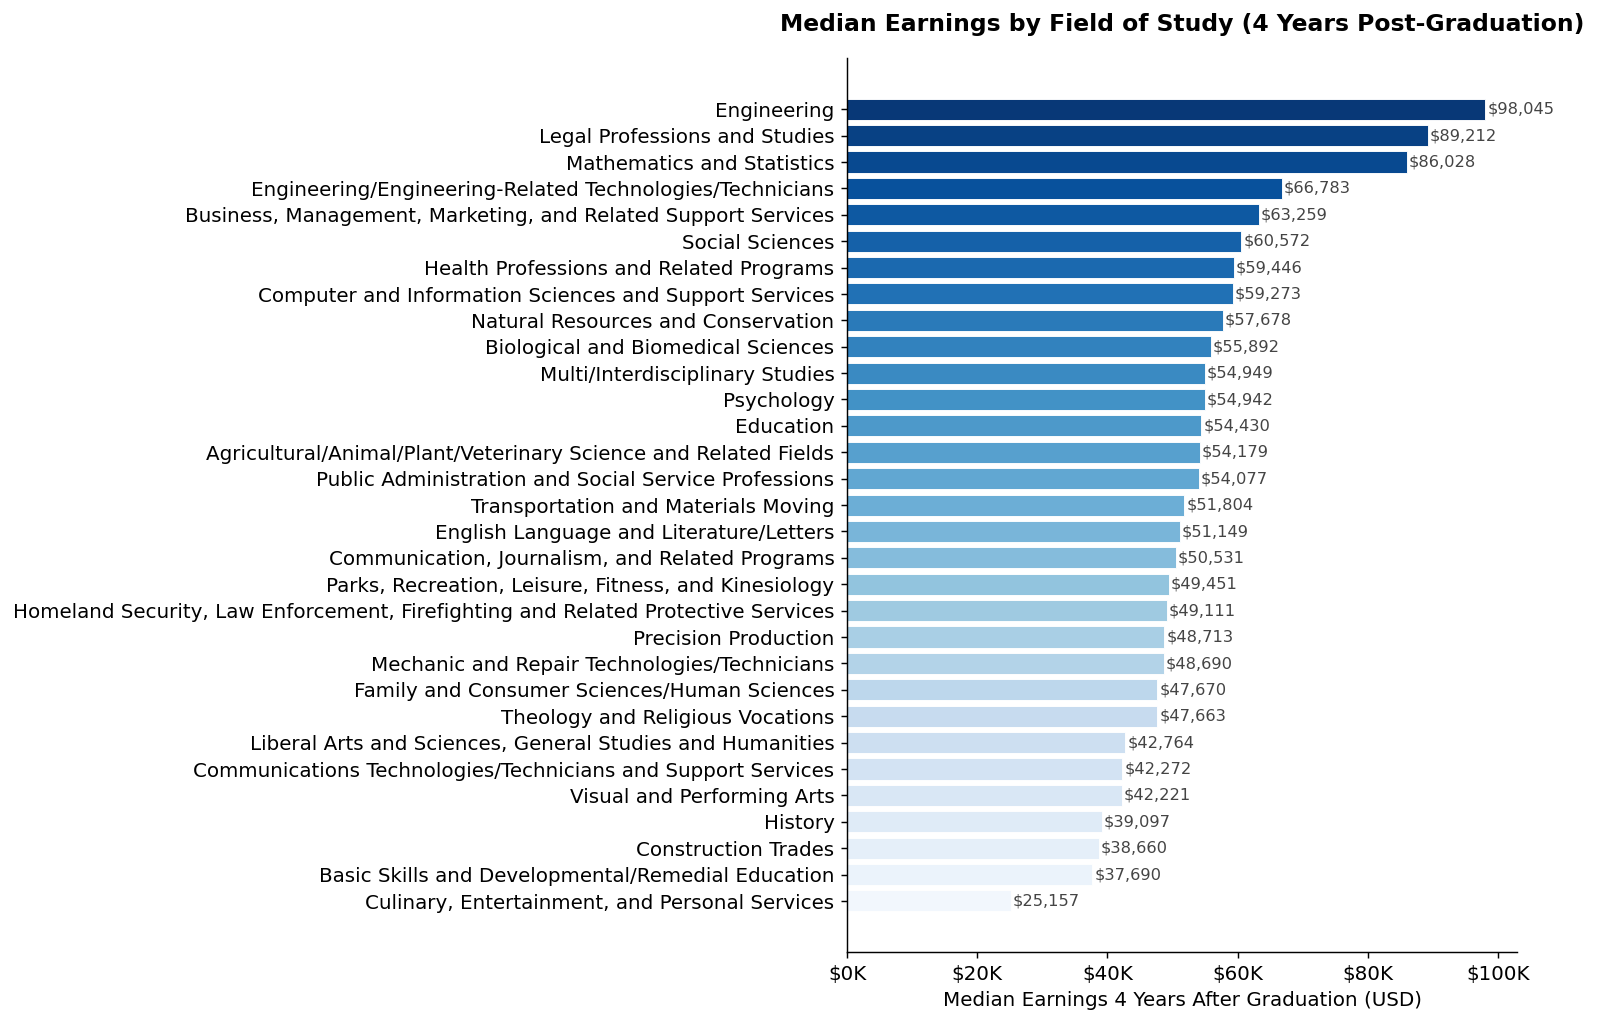

💾 Đã lưu: plot1_earnings_by_field.png


In [29]:
# Tính median theo cip_family_title (nhóm ngành cấp cao), loại bỏ NaN
earnings_by_field = (
    df.dropna(subset=["median_earnings_4yr_usd", "cip_family_title"])
    .groupby("cip_family_title")["median_earnings_4yr_usd"]
    .median()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 8))
colors = sns.color_palette("Blues_r", n_colors=len(earnings_by_field))

bars = ax.barh(
    earnings_by_field.index,
    earnings_by_field.values,
    color=colors,
    edgecolor="white",
    linewidth=0.5,
)

# Thêm nhãn giá trị bên phải mỗi thanh
for bar, val in zip(bars, earnings_by_field.values):
    ax.text(
        val + 300, bar.get_y() + bar.get_height() / 2,
        f"${val:,.0f}",
        va="center", ha="left", fontsize=9, color="#444"
    )

ax.set_xlabel("Median Earnings 4 Years After Graduation (USD)", fontsize=11)
ax.set_title(
    "Median Earnings by Field of Study (4 Years Post-Graduation)",
    fontsize=13, fontweight="bold", pad=15
)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))
ax.invert_yaxis()   # Nhóm thu nhập cao nhất ở đầu
plt.tight_layout()
plt.savefig("plot1_earnings_by_field.png", bbox_inches="tight")
plt.show()
print("💾 Đã lưu: plot1_earnings_by_field.png")

### **4.2  BIỂU ĐỒ: Tương quan AI Exposure vs Thu nhập**

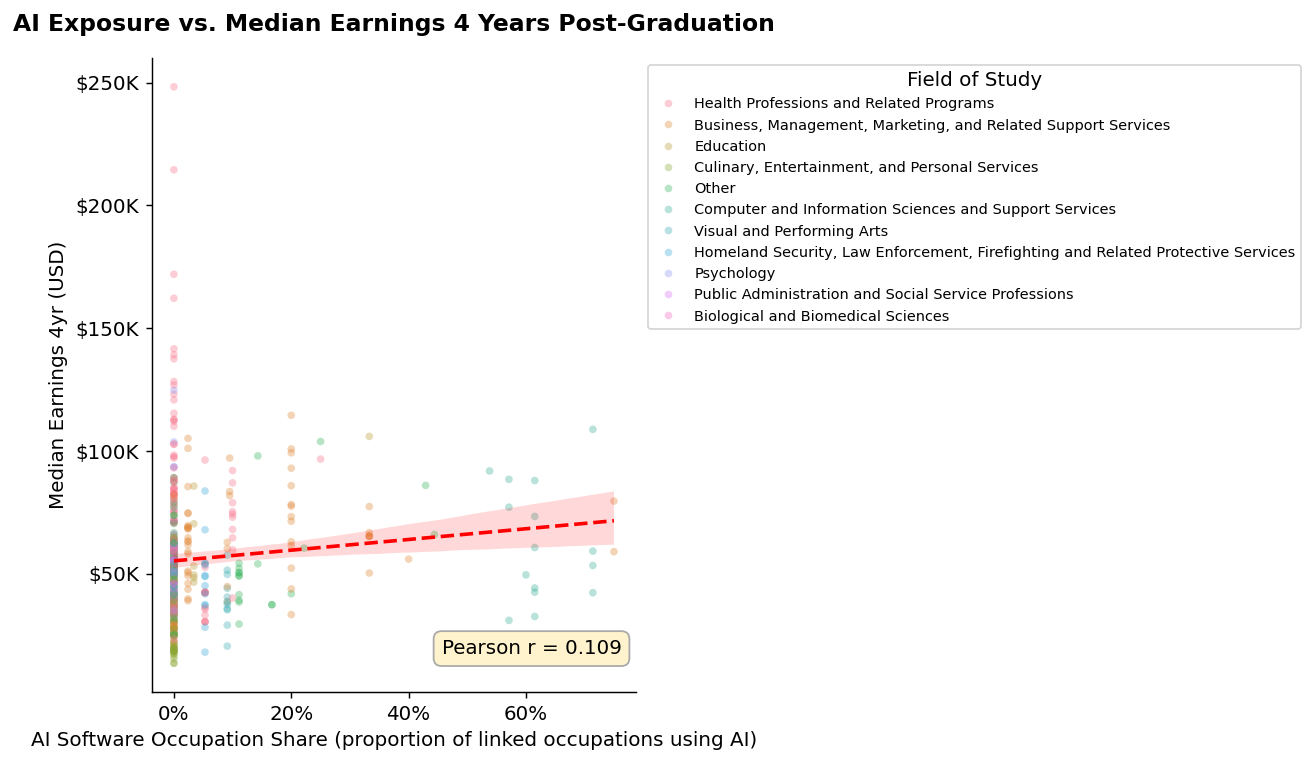

💾 Đã lưu: plot2_ai_vs_earnings.png
📌 Pearson r = 0.109 — tương quan thuận giữa AI exposure và thu nhập


In [30]:
# Dùng ai_software_occupation_share làm proxy cho "AI Exposure"
# (tỷ lệ nghề nghiệp liên kết với chương trình sử dụng AI software)

# Lọc dữ liệu hợp lệ
scatter_df = df.dropna(subset=["ai_software_occupation_share", "median_earnings_4yr_usd"]).copy()

# Tính correlation coefficient để hiển thị trên biểu đồ
corr = scatter_df["ai_software_occupation_share"].corr(scatter_df["median_earnings_4yr_usd"])

fig, ax = plt.subplots(figsize=(10, 6))

# Tô màu điểm theo nhóm ngành để dễ nhận dạng
# Chọn top-10 nhóm ngành có nhiều dữ liệu nhất để tô màu riêng
top_fields = scatter_df["cip_family_title"].value_counts().head(10).index
scatter_df["field_group"] = scatter_df["cip_family_title"].where(
    scatter_df["cip_family_title"].isin(top_fields), other="Other"
)

sns.scatterplot(
    data=scatter_df,
    x="ai_software_occupation_share",
    y="median_earnings_4yr_usd",
    hue="field_group",
    alpha=0.35,
    s=18,
    linewidth=0,
    ax=ax,
)

# Đường xu hướng tổng thể (regression line)
sns.regplot(
    data=scatter_df,
    x="ai_software_occupation_share",
    y="median_earnings_4yr_usd",
    scatter=False,
    color="red",
    line_kws={"linewidth": 2, "linestyle": "--", "label": f"Trend (r = {corr:.2f})"},
    ax=ax,
)

ax.set_xlabel("AI Software Occupation Share (proportion of linked occupations using AI)", fontsize=11)
ax.set_ylabel("Median Earnings 4yr (USD)", fontsize=11)
ax.set_title(
    "AI Exposure vs. Median Earnings 4 Years Post-Graduation",
    fontsize=13, fontweight="bold", pad=15
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

# Chú thích correlation
ax.annotate(
    f"Pearson r = {corr:.3f}",
    xy=(0.97, 0.06), xycoords="axes fraction",
    ha="right", fontsize=11,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#fff3cd", edgecolor="#aaa"),
)

ax.legend(title="Field of Study", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("plot2_ai_vs_earnings.png", bbox_inches="tight")
plt.show()
print(f"💾 Đã lưu: plot2_ai_vs_earnings.png")
print(f"📌 Pearson r = {corr:.3f} — {'tương quan thuận' if corr > 0 else 'tương quan nghịch'} giữa AI exposure và thu nhập")

### **4.3 BIỂU ĐỒ: Top 10 Debt-to-Earnings cao nhất & thấp nhất**

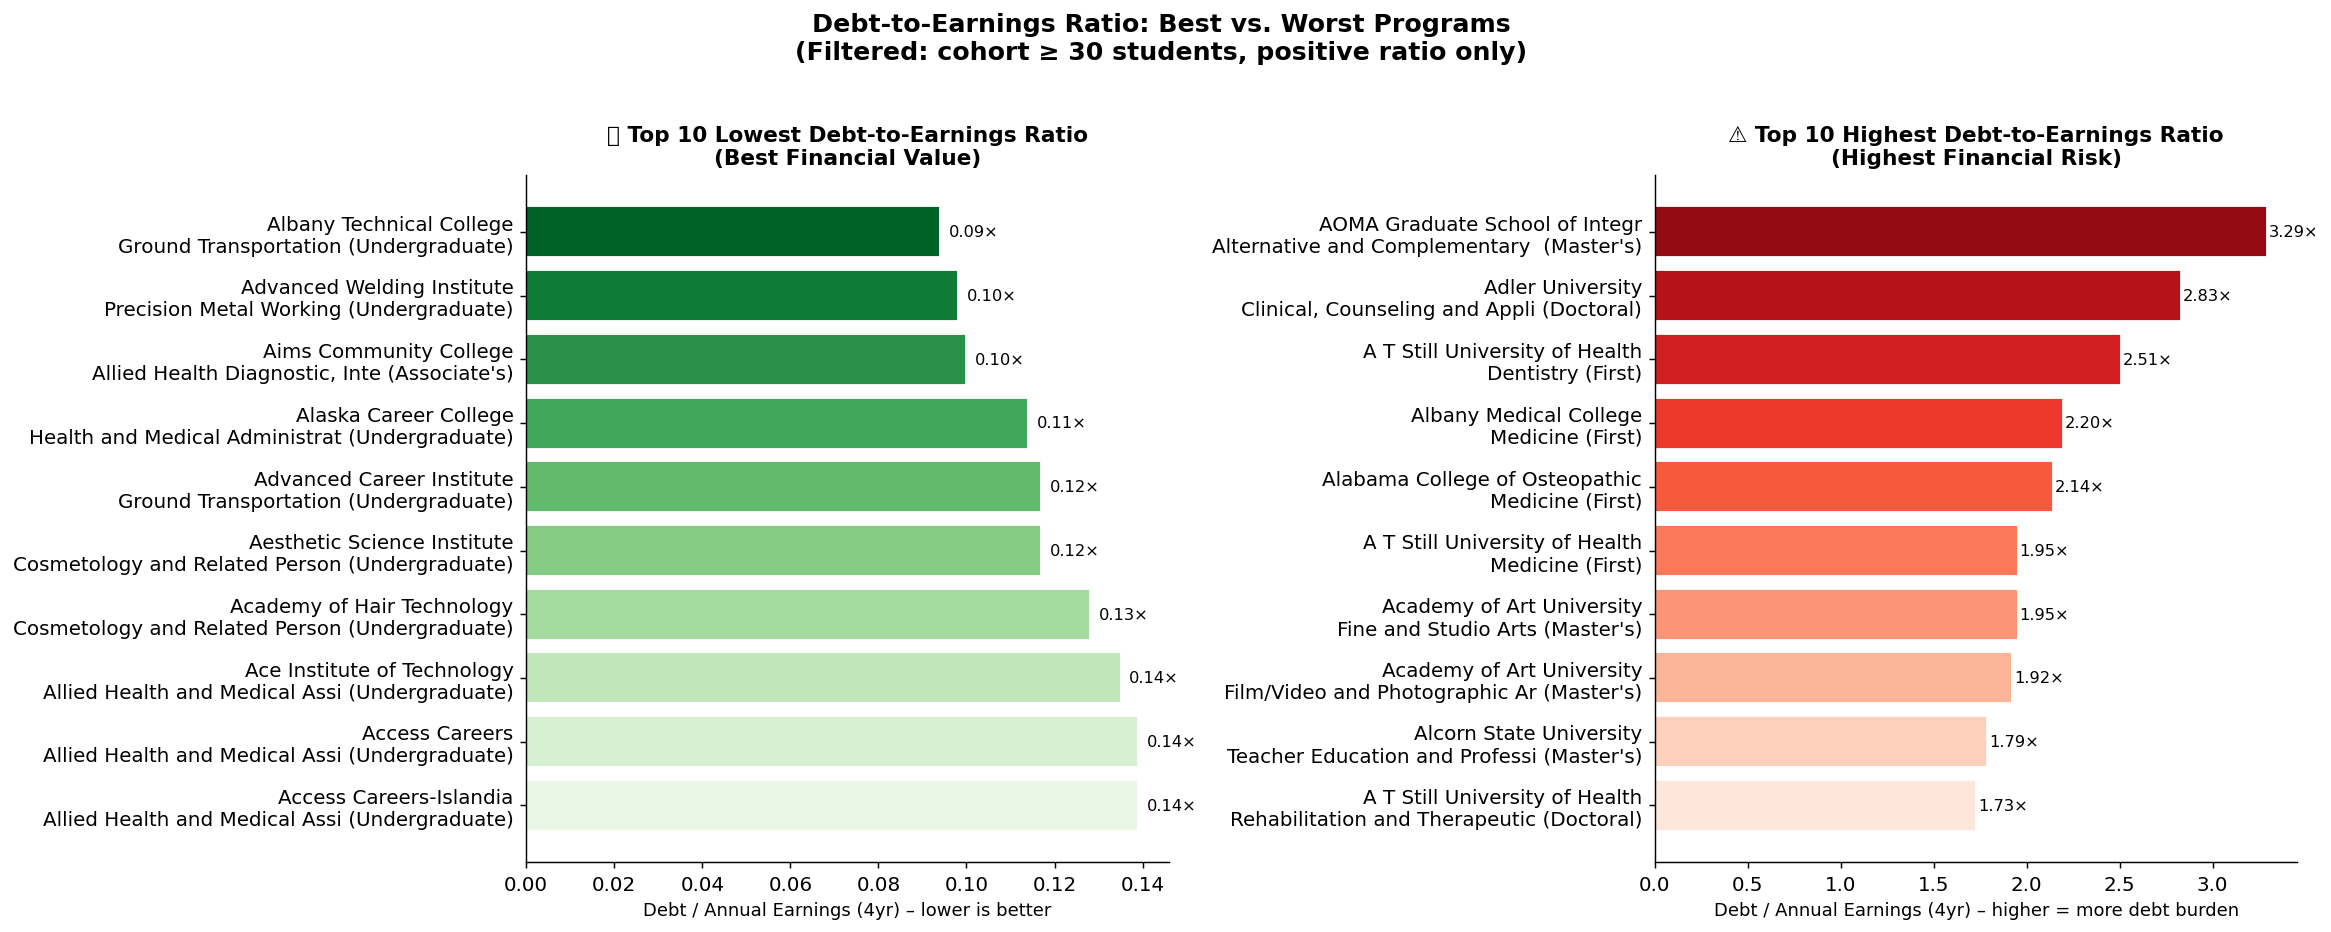

💾 Đã lưu: plot3_debt_to_earnings.png


In [31]:
# Dùng debt_to_earnings_4yr = median_debt_usd / median_earnings_4yr_usd
# Loại bỏ NaN, giá trị âm, và các chương trình có cohort quá nhỏ (<30 sinh viên)
# để kết quả đáng tin cậy hơn

dte_df = df.dropna(subset=["debt_to_earnings_4yr", "median_earnings_4yr_usd"]).copy()
dte_df = dte_df[
    (dte_df["debt_to_earnings_4yr"] > 0) &
    (dte_df["earnings_cohort_size_4yr"].fillna(0) >= 30)
].copy()

# Tạo nhãn ngắn cho biểu đồ: Tên trường + tên chương trình
dte_df["label"] = (
    dte_df["institution_name"].fillna("Unknown").str[:30]
    + "\n"
    + dte_df["cip_title"].fillna("").str[:30]
    + " ("
    + dte_df["credential_name"].fillna("").str.split().str[0]
    + ")"
)

top10_low  = dte_df.nsmallest(10, "debt_to_earnings_4yr")[["label", "debt_to_earnings_4yr"]]
top10_high = dte_df.nlargest(10, "debt_to_earnings_4yr")[["label", "debt_to_earnings_4yr"]]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Subplot trái: DTE thấp nhất (hiệu quả tài chính tốt nhất) ---
axes[0].barh(
    top10_low["label"].str.strip(),
    top10_low["debt_to_earnings_4yr"],
    color=sns.color_palette("Greens_r", 10),
    edgecolor="white",
)
for i, val in enumerate(top10_low["debt_to_earnings_4yr"]):
    axes[0].text(val + 0.002, i, f"{val:.2f}×", va="center", fontsize=9)
axes[0].set_title("✅ Top 10 Lowest Debt-to-Earnings Ratio\n(Best Financial Value)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Debt / Annual Earnings (4yr) – lower is better", fontsize=10)
axes[0].invert_yaxis()

# --- Subplot phải: DTE cao nhất (rủi ro tài chính cao nhất) ---
axes[1].barh(
    top10_high["label"].str.strip(),
    top10_high["debt_to_earnings_4yr"],
    color=sns.color_palette("Reds_r", 10),
    edgecolor="white",
)
for i, val in enumerate(top10_high["debt_to_earnings_4yr"]):
    axes[1].text(val + 0.01, i, f"{val:.2f}×", va="center", fontsize=9)
axes[1].set_title("⚠️ Top 10 Highest Debt-to-Earnings Ratio\n(Highest Financial Risk)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Debt / Annual Earnings (4yr) – higher = more debt burden", fontsize=10)
axes[1].invert_yaxis()

plt.suptitle(
    "Debt-to-Earnings Ratio: Best vs. Worst Programs\n"
    "(Filtered: cohort ≥ 30 students, positive ratio only)",
    fontsize=14, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.savefig("plot3_debt_to_earnings.png", bbox_inches="tight")
plt.show()
print("💾 Đã lưu: plot3_debt_to_earnings.png")

### **PHẦN BỔ SUNG: KIỂM ĐỊNH CÁC GIẢ THUYẾT (HYPOTHESIS TESTING)**

In [10]:
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm

print("✅ Thư viện thống kê đã sẵn sàng.")

✅ Thư viện thống kê đã sẵn sàng.


***H1.1: So sánh Pearson r trong từng nhóm ngành (within-field correlation)***

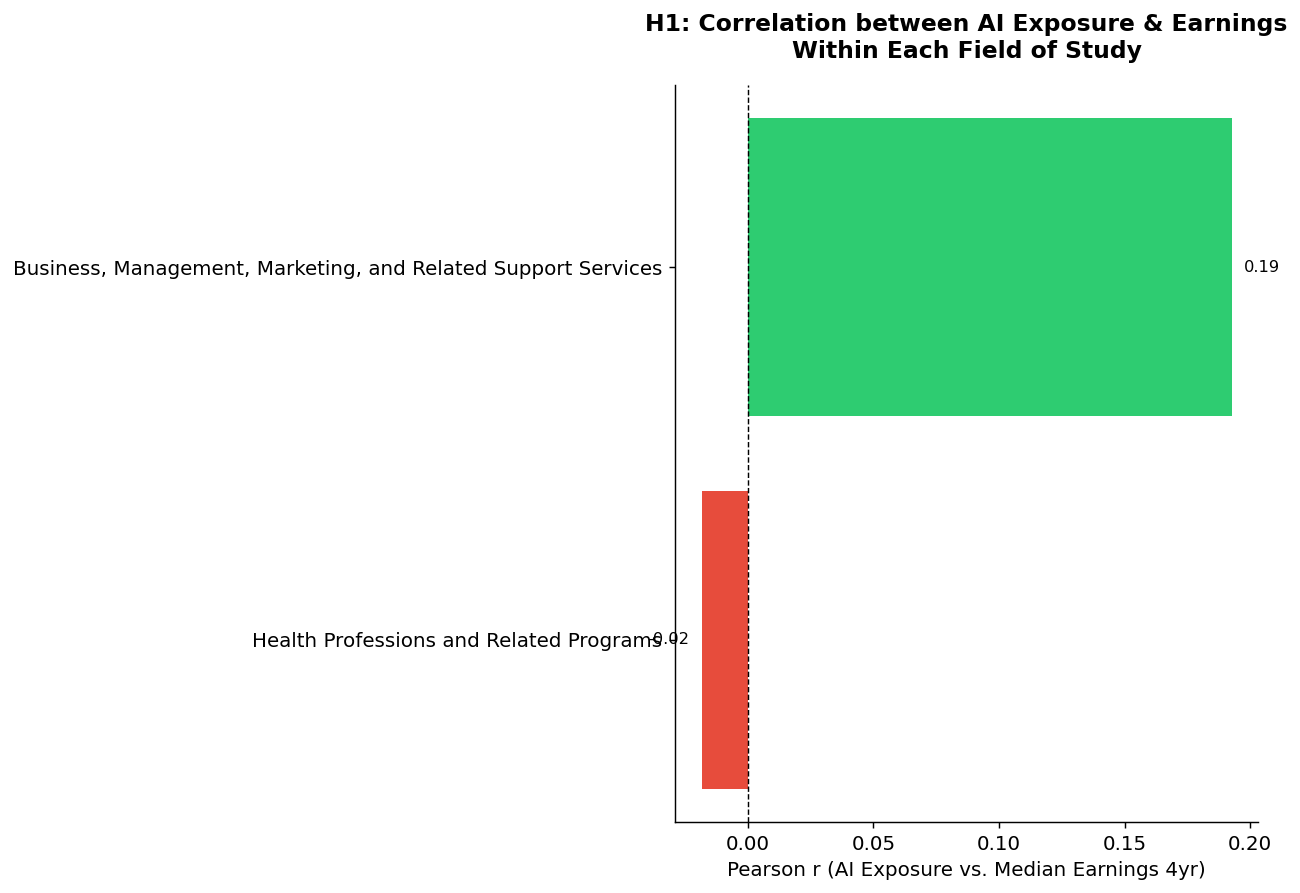

💾 plot4_h1_within_field_corr.png


In [11]:
h1_df = df.dropna(subset=["ai_software_occupation_share", "median_earnings_4yr_usd", "cip_family_title"]).copy()

within_corr = (
    h1_df.groupby("cip_family_title")
    .apply(lambda g: g["ai_software_occupation_share"].corr(g["median_earnings_4yr_usd"])
           if len(g) >= 30 else np.nan)
    .dropna()
    .sort_values(ascending=False)
    .rename("pearson_r")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#2ecc71" if r > 0 else "#e74c3c" for r in within_corr["pearson_r"]]
bars = ax.barh(within_corr["cip_family_title"], within_corr["pearson_r"], color=colors)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
for bar, val in zip(bars, within_corr["pearson_r"]):
    ax.text(val + (0.005 if val >= 0 else -0.005), bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}", va="center", ha="left" if val >= 0 else "right", fontsize=9)
ax.set_xlabel("Pearson r (AI Exposure vs. Median Earnings 4yr)", fontsize=11)
ax.set_title(
    "H1: Correlation between AI Exposure & Earnings\nWithin Each Field of Study",
    fontsize=13, fontweight="bold", pad=15
)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("plot4_h1_within_field_corr.png", bbox_inches="tight")
plt.show()
print("💾 plot4_h1_within_field_corr.png")

***H1.2: OLS Regression có kiểm soát nhóm ngành (fixed effects đơn giản): Nếu AI vẫn có hệ số dương sau khi thêm nhóm ngành vào model → H1 được ủng hộ***

In [12]:
h1_model_df = h1_df.dropna(subset=["median_earnings_4yr_usd", "ai_software_occupation_share"]).copy()
h1_model_df["log_earnings"] = np.log(h1_model_df["median_earnings_4yr_usd"])

# Dùng C() để tạo dummy variables cho nhóm ngành
formula = "log_earnings ~ ai_software_occupation_share + C(cip_family_title)"
model_h1 = smf.ols(formula, data=h1_model_df).fit()

print("\n📊 H1 – OLS Regression (Earnings ~ AI Exposure + Field of Study Fixed Effects):")
print(f"   R²       = {model_h1.rsquared:.3f}")
print(f"   AI coeff = {model_h1.params['ai_software_occupation_share']:.4f}")
print(f"   AI p-val = {model_h1.pvalues['ai_software_occupation_share']:.4f}")
ai_sig = "✅ Có ý nghĩa thống kê (p < 0.05)" if model_h1.pvalues['ai_software_occupation_share'] < 0.05 else "❌ Không có ý nghĩa thống kê"
print(f"   → {ai_sig}")


📊 H1 – OLS Regression (Earnings ~ AI Exposure + Field of Study Fixed Effects):
   R²       = 0.366
   AI coeff = 0.3805
   AI p-val = 0.1291
   → ❌ Không có ý nghĩa thống kê


***H2 – MỐI QUAN HỆ PHI TUYẾN GIỮA AI EXPOSURE VÀ THU NHẬP - Câu hỏi: Có ngưỡng AI exposure mà dưới đó không có tác động?***

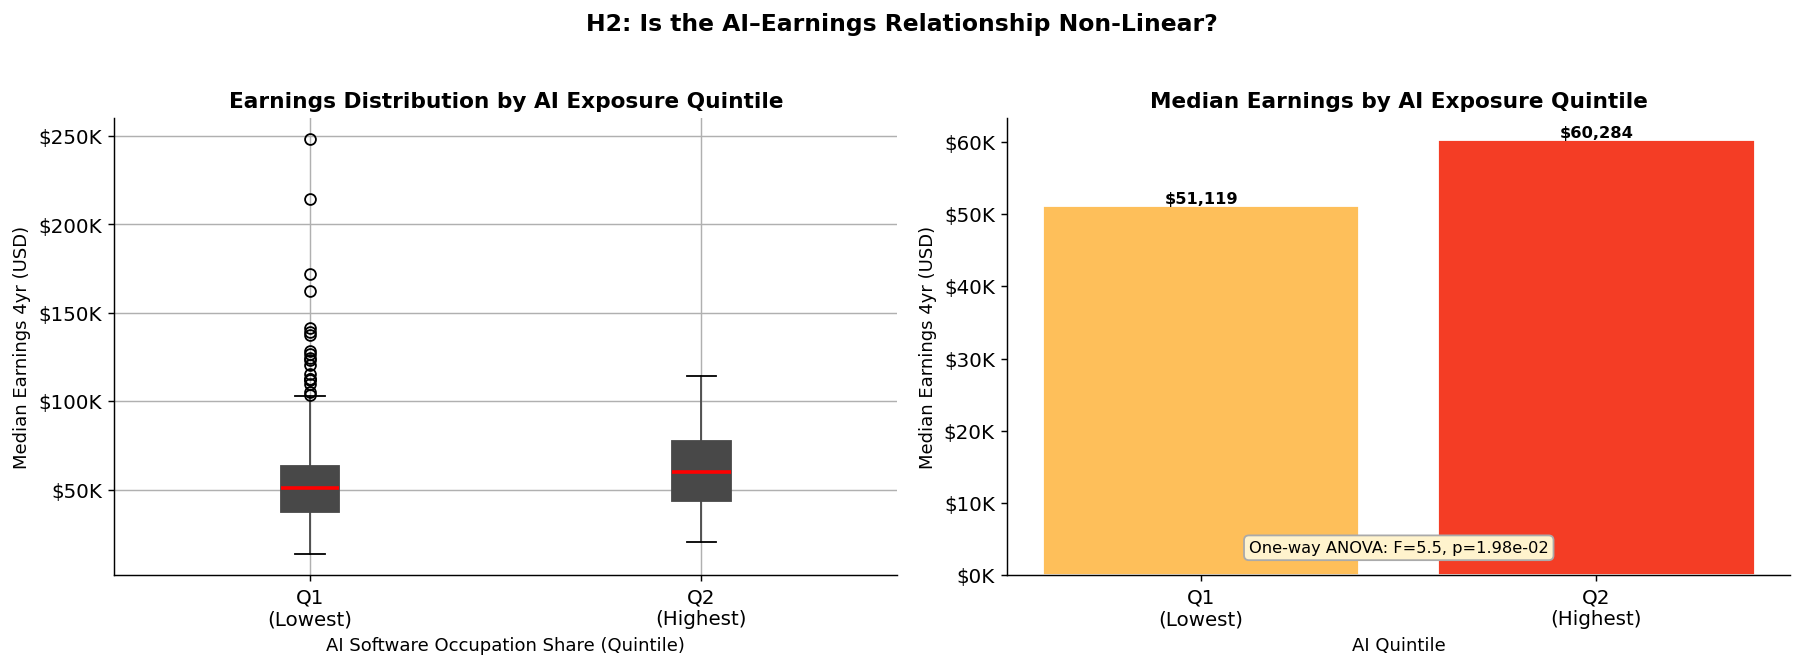

💾 plot5_h2_ai_nonlinear.png


In [14]:
h2_df = df.dropna(subset=["ai_software_occupation_share", "median_earnings_4yr_usd"]).copy()
temp_cat = pd.qcut(
    h2_df["ai_software_occupation_share"], q=5,
    duplicates='drop',
    labels=False, # Trả về chỉ số nguyên của bin
    retbins=False # Không trả về các cạnh bin
)

# Lấy số lượng phân vị duy nhất thực tế được tạo
num_actual_quantiles = temp_cat.nunique()

# Tạo nhãn dựa trên số lượng phân vị thực tế
if num_actual_quantiles > 0:
    generated_labels = [f"Q{i+1}" for i in range(num_actual_quantiles)]
    # Custom labels for the first and last quantiles if they exist
    if num_actual_quantiles >= 1:
        generated_labels[0] = "Q1\n(Lowest)"
    if num_actual_quantiles >= 2:
        generated_labels[-1] = f"Q{num_actual_quantiles}\n(Highest)"
else:
    generated_labels = [] # This case might need further handling if no quantiles can be formed

# Áp dụng qcut với các nhãn đã điều chỉnh
h2_df["ai_quintile"] = pd.qcut(
    h2_df["ai_software_occupation_share"], q=5,
    labels=generated_labels,
    duplicates='drop'
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot thu nhập theo quintile AI
h2_df.boxplot(
    column="median_earnings_4yr_usd",
    by="ai_quintile",
    ax=axes[0],
    patch_artist=True,
    medianprops=dict(color="red", linewidth=2),
)
axes[0].set_title("Earnings Distribution by AI Exposure Quintile", fontsize=12, fontweight="bold")
axes[0].set_xlabel("AI Software Occupation Share (Quintile)", fontsize=10)
axes[0].set_ylabel("Median Earnings 4yr (USD)", fontsize=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))
axes[0].get_figure().suptitle("")   # Xóa auto-title của boxplot

# Median earnings theo quintile + bar chart
quintile_medians = h2_df.groupby("ai_quintile", observed=True)["median_earnings_4yr_usd"].median()
palette = sns.color_palette("YlOrRd", len(quintile_medians))
bars = axes[1].bar(quintile_medians.index, quintile_medians.values, color=palette, edgecolor="white")
for bar, val in zip(bars, quintile_medians.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 300, f"${val:,.0f}",
                 ha="center", fontsize=9, fontweight="bold")
axes[1].set_title("Median Earnings by AI Exposure Quintile", fontsize=12, fontweight="bold")
axes[1].set_xlabel("AI Quintile", fontsize=10)
axes[1].set_ylabel("Median Earnings 4yr (USD)", fontsize=10)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))

# ANOVA test: liệu có sự khác biệt có ý nghĩa giữa các quintile không?
groups = [group["median_earnings_4yr_usd"].dropna().values
          for _, group in h2_df.groupby("ai_quintile", observed=True)]
f_stat, p_val = stats.f_oneway(*groups)
axes[1].annotate(f"One-way ANOVA: F={f_stat:.1f}, p={p_val:.2e}",
                 xy=(0.5, 0.05), xycoords="axes fraction", ha="center", fontsize=9,
                 bbox=dict(boxstyle="round", facecolor="#fff3cd", edgecolor="#aaa"))

plt.suptitle("H2: Is the AI–Earnings Relationship Non-Linear?", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("plot5_h2_ai_nonlinear.png", bbox_inches="tight")
plt.show()
print("💾 plot5_h2_ai_nonlinear.png")

H3 – AI EXPOSURE DỰ BÁO TỐC ĐỘ TĂNG TRƯỞNG THU NHẬP TỐT HƠN LÀ MỨC THU NHẬP TUYỆT ĐỐI?

Logic kiểm định:
- Model A: earnings_4yr ~ ai_exposure              (dự báo mức tuyệt đối)
- Model B: earnings_growth_1yr_to_5yr ~ ai_exposure (dự báo tốc độ tăng)

So sánh R² của hai model → model nào fit tốt hơn?
Nếu R²_B > R²_A → AI exposure dự báo growth tốt hơn level → H3 được ủng hộ.

📊 H3 Dataset: 271 chương trình có đủ dữ liệu earnings 1yr + 5yr

   Model A (AI → Earnings Level):
     R² = 0.0181 | coef = 0.5029 | p = 0.0266

   Model B (AI → Earnings Growth):
     R² = 0.0174 | coef = 39.9806 | p = 0.0298

   → ❌ H3 không được ủng hộ: AI dự báo LEVEL tốt hơn GROWTH


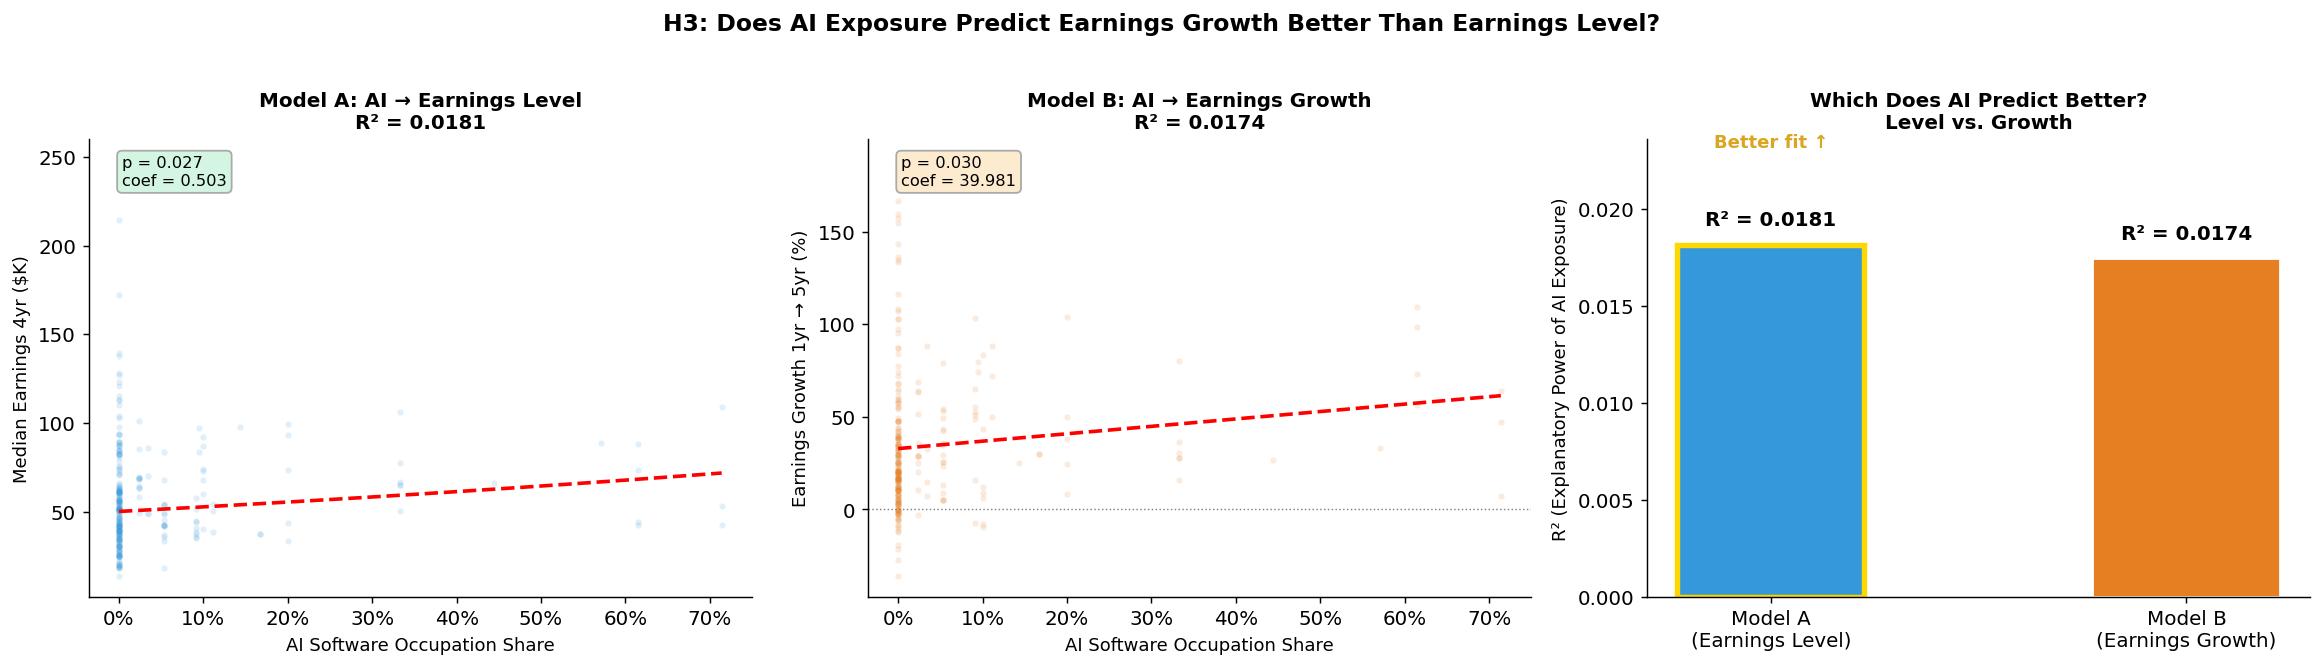

💾 plot_h3_ai_level_vs_growth.png

📌 Kết luận H3: ❌ H3 không được ủng hộ: AI dự báo LEVEL tốt hơn GROWTH


In [15]:
h3_df = df.dropna(subset=[
    "ai_software_occupation_share",
    "median_earnings_1yr_usd",
    "median_earnings_4yr_usd",
    "median_earnings_5yr_usd",
]).copy()

# Loại bỏ các dòng có earnings_1yr = 0 để tránh chia cho 0
h3_df = h3_df[h3_df["median_earnings_1yr_usd"] > 5000].copy()

# Tính earnings growth (%) từ năm 1 đến năm 5
h3_df["growth_1yr_to_5yr_pct"] = (
    (h3_df["median_earnings_5yr_usd"] - h3_df["median_earnings_1yr_usd"])
    / h3_df["median_earnings_1yr_usd"] * 100
)

# Log-transform earnings để normalize phân phối lệch phải
h3_df["log_earnings_4yr"] = np.log(h3_df["median_earnings_4yr_usd"])

# Loại outlier growth cực đoan (>200% hoặc âm sâu <-50%)
h3_df = h3_df[
    (h3_df["growth_1yr_to_5yr_pct"] > -50) &
    (h3_df["growth_1yr_to_5yr_pct"] < 200)
].copy()

print(f"📊 H3 Dataset: {len(h3_df):,} chương trình có đủ dữ liệu earnings 1yr + 5yr")

# ── Model A: AI → Earnings Level (4yr) ─────────────────────────────────────
model_A = smf.ols("log_earnings_4yr ~ ai_software_occupation_share", data=h3_df).fit()
r2_A = model_A.rsquared
coef_A = model_A.params["ai_software_occupation_share"]
pval_A = model_A.pvalues["ai_software_occupation_share"]

# ── Model B: AI → Earnings Growth (1yr→5yr) ────────────────────────────────
model_B = smf.ols("growth_1yr_to_5yr_pct ~ ai_software_occupation_share", data=h3_df).fit()
r2_B = model_B.rsquared
coef_B = model_B.params["ai_software_occupation_share"]
pval_B = model_B.pvalues["ai_software_occupation_share"]

print(f"\n   Model A (AI → Earnings Level):")
print(f"     R² = {r2_A:.4f} | coef = {coef_A:.4f} | p = {pval_A:.4f}")
print(f"\n   Model B (AI → Earnings Growth):")
print(f"     R² = {r2_B:.4f} | coef = {coef_B:.4f} | p = {pval_B:.4f}")
verdict = "✅ H3 được ủng hộ: AI dự báo GROWTH tốt hơn LEVEL" if r2_B > r2_A \
          else "❌ H3 không được ủng hộ: AI dự báo LEVEL tốt hơn GROWTH"
print(f"\n   → {verdict}")

# ── Vẽ biểu đồ ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot trái: AI vs Earnings Level (scatter + regression) ---
axes[0].scatter(
    h3_df["ai_software_occupation_share"],
    h3_df["median_earnings_4yr_usd"] / 1000,
    alpha=0.15, s=12, color="#3498db", linewidths=0
)
# Đường regression
x_range = np.linspace(h3_df["ai_software_occupation_share"].min(),
                      h3_df["ai_software_occupation_share"].max(), 100)
# Dùng giá trị thật (không log) để plot — ước lượng từ log model
y_pred_A = np.exp(model_A.params["Intercept"] + model_A.params["ai_software_occupation_share"] * x_range) / 1000
axes[0].plot(x_range, y_pred_A, color="red", linewidth=2, linestyle="--")
axes[0].set_xlabel("AI Software Occupation Share", fontsize=10)
axes[0].set_ylabel("Median Earnings 4yr ($K)", fontsize=10)
axes[0].set_title(f"Model A: AI → Earnings Level\nR² = {r2_A:.4f}", fontsize=11, fontweight="bold")
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
axes[0].annotate(f"p = {pval_A:.3f}\ncoef = {coef_A:.3f}",
                 xy=(0.05, 0.90), xycoords="axes fraction", fontsize=9,
                 bbox=dict(boxstyle="round", facecolor="#d5f5e3", edgecolor="#aaa"))

# --- Plot tengah: AI vs Earnings Growth (scatter + regression) ---
axes[1].scatter(
    h3_df["ai_software_occupation_share"],
    h3_df["growth_1yr_to_5yr_pct"],
    alpha=0.15, s=12, color="#e67e22", linewidths=0
)
y_pred_B = model_B.params["Intercept"] + model_B.params["ai_software_occupation_share"] * x_range
axes[1].plot(x_range, y_pred_B, color="red", linewidth=2, linestyle="--")
axes[1].set_xlabel("AI Software Occupation Share", fontsize=10)
axes[1].set_ylabel("Earnings Growth 1yr → 5yr (%)", fontsize=10)
axes[1].set_title(f"Model B: AI → Earnings Growth\nR² = {r2_B:.4f}", fontsize=11, fontweight="bold")
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
axes[1].axhline(0, color="gray", linewidth=0.8, linestyle=":")
axes[1].annotate(f"p = {pval_B:.3f}\ncoef = {coef_B:.3f}",
                 xy=(0.05, 0.90), xycoords="axes fraction", fontsize=9,
                 bbox=dict(boxstyle="round", facecolor="#fdebd0", edgecolor="#aaa"))

# --- Plot phải: R² comparison bar chart ---
metrics = ["Model A\n(Earnings Level)", "Model B\n(Earnings Growth)"]
r2_vals = [r2_A, r2_B]
bar_colors = ["#3498db", "#e67e22"]
bars = axes[2].bar(metrics, r2_vals, color=bar_colors, edgecolor="white", width=0.45)
for bar, val in zip(bars, r2_vals):
    axes[2].text(bar.get_x() + bar.get_width() / 2,
                 val + 0.001,
                 f"R² = {val:.4f}",
                 ha="center", fontsize=11, fontweight="bold")

# Đánh dấu model nào tốt hơn
winner_idx = 1 if r2_B > r2_A else 0
bars[winner_idx].set_edgecolor("gold")
bars[winner_idx].set_linewidth(3)
axes[2].annotate("Better fit ↑",
                 xy=(winner_idx, r2_vals[winner_idx]),
                 xytext=(winner_idx, r2_vals[winner_idx] + 0.005),
                 ha="center", fontsize=10, color="goldenrod", fontweight="bold")

axes[2].set_ylabel("R² (Explanatory Power of AI Exposure)", fontsize=10)
axes[2].set_title("Which Does AI Predict Better?\nLevel vs. Growth", fontsize=11, fontweight="bold")
axes[2].set_ylim(0, max(r2_vals) * 1.3)

plt.suptitle(
    "H3: Does AI Exposure Predict Earnings Growth Better Than Earnings Level?",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("plot_h3_ai_level_vs_growth.png", bbox_inches="tight")
plt.show()
print("💾 plot_h3_ai_level_vs_growth.png")
print(f"\n📌 Kết luận H3: {verdict}")

***H4 – LOẠI TRƯỜNG VÀ DEBT-TO-EARNINGS (kiểm soát ngành & bằng cấp) - Câu hỏi: Private for-profit có DTE tệ hơn Public trong cùng điều kiện?***

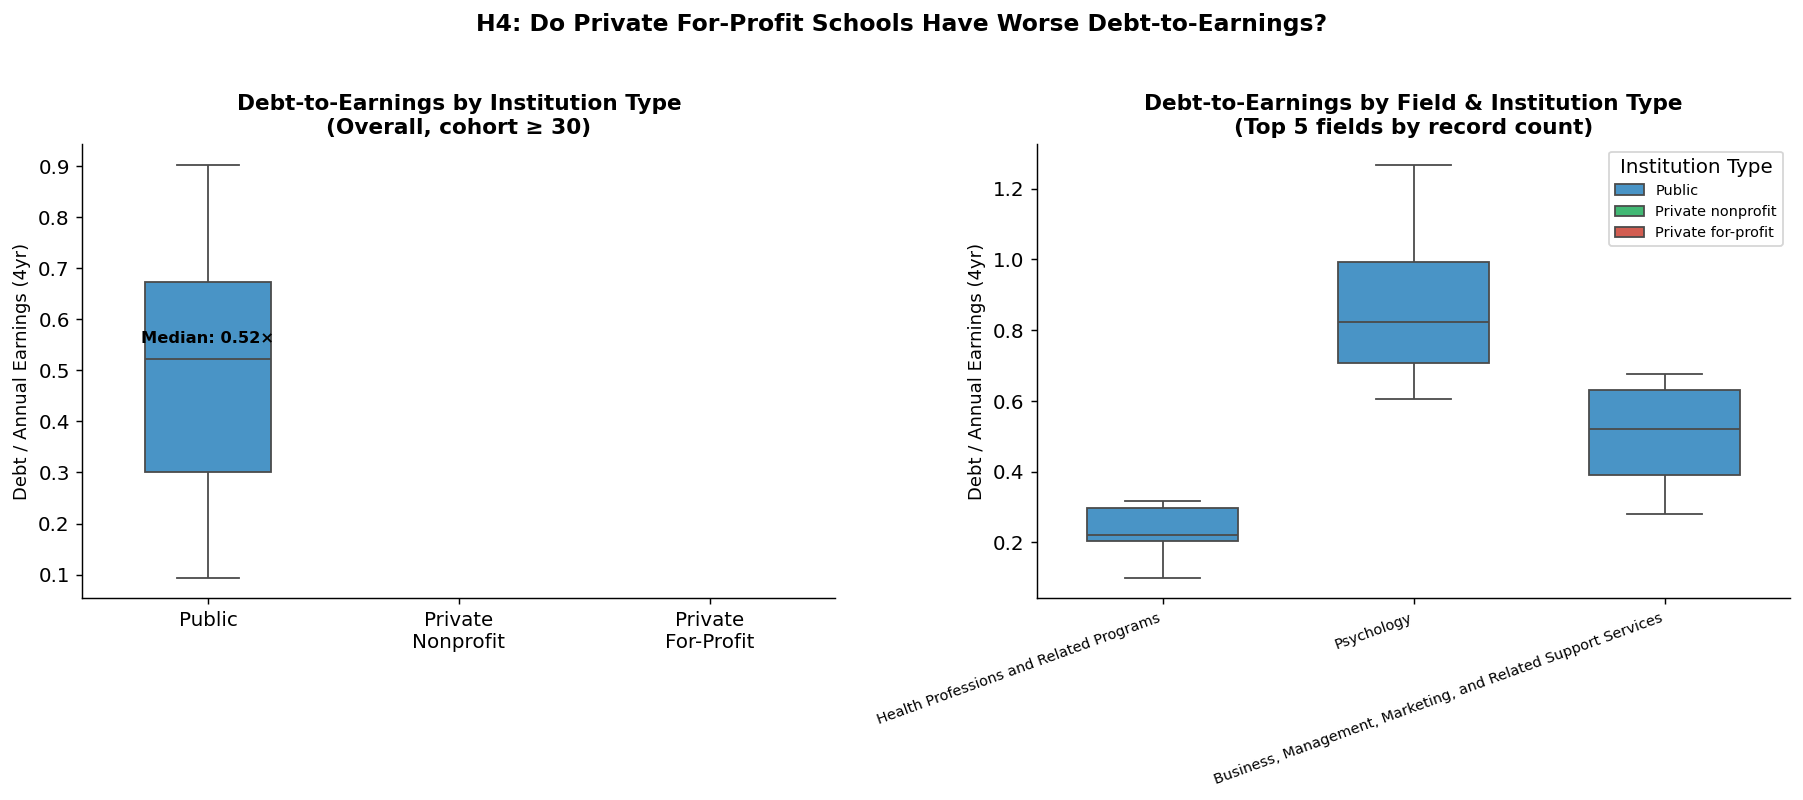

📊 H4 – Kruskal-Wallis test: H=nan, p=nan
   → ❌ Không có sự khác biệt có ý nghĩa giữa 3 loại trường
💾 plot6_h4_institution_dte.png


In [17]:
h4_df = df.dropna(subset=["debt_to_earnings_4yr", "institution_control", "cip_family_title", "credential_name"]).copy()
h4_df = h4_df[
    (h4_df["debt_to_earnings_4yr"] > 0) &
    (h4_df["debt_to_earnings_4yr"] < 10) &   # Loại outlier cực đoan
    (h4_df["earnings_cohort_size_4yr"].fillna(0) >= 30)
].copy()

# ── H4.1: Box plot DTE theo loại trường ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

order = ["Public", "Private nonprofit", "Private for-profit"]
palette_h4 = {"Public": "#3498db", "Private nonprofit": "#2ecc71", "Private for-profit": "#e74c3c"}

# Box plot tổng thể
sns.boxplot(
    data=h4_df[h4_df["institution_control"].isin(order)],
    x="institution_control", y="debt_to_earnings_4yr",
    order=order, palette=palette_h4, ax=axes[0],
    showfliers=False,  # Ẩn outlier để dễ đọc
    width=0.5,
)
axes[0].set_title("Debt-to-Earnings by Institution Type\n(Overall, cohort ≥ 30)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Debt / Annual Earnings (4yr)", fontsize=10)
axes[0].set_xticklabels(["Public", "Private\nNonprofit", "Private\nFor-Profit"])

# Thêm số median lên mỗi box
for i, ctrl in enumerate(order):
    subset = h4_df[h4_df["institution_control"] == ctrl]["debt_to_earnings_4yr"]
    med = subset.median()
    axes[0].text(i, med + 0.03, f"Median: {med:.2f}×", ha="center", fontsize=9, fontweight="bold")

# ── H4.2: Violin plot theo nhóm ngành × loại trường ────────────────────────
top5_fields = h4_df["cip_family_title"].value_counts().head(5).index
h4_sub = h4_df[h4_df["cip_family_title"].isin(top5_fields) &
               h4_df["institution_control"].isin(order)].copy()

sns.boxplot(
    data=h4_sub,
    x="cip_family_title", y="debt_to_earnings_4yr",
    hue="institution_control", hue_order=order,
    palette=palette_h4, ax=axes[1],
    showfliers=False, width=0.6,
)
axes[1].set_title("Debt-to-Earnings by Field & Institution Type\n(Top 5 fields by record count)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Debt / Annual Earnings (4yr)", fontsize=10)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha="right", fontsize=8)
axes[1].legend(title="Institution Type", fontsize=8, loc="upper right")

plt.suptitle("H4: Do Private For-Profit Schools Have Worse Debt-to-Earnings?", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("plot6_h4_institution_dte.png", bbox_inches="tight")
plt.show()

# Kruskal-Wallis test (không giả định phân phối chuẩn)
groups_h4 = [h4_df[h4_df["institution_control"] == ctrl]["debt_to_earnings_4yr"].dropna()
             for ctrl in order]
h_stat, p_h4 = stats.kruskal(*groups_h4)
print(f"📊 H4 – Kruskal-Wallis test: H={h_stat:.1f}, p={p_h4:.2e}")
print(f"   → {'✅ Có sự khác biệt có ý nghĩa thống kê' if p_h4 < 0.05 else '❌ Không có sự khác biệt có ý nghĩa'} giữa 3 loại trường")
print("💾 plot6_h4_institution_dte.png")

***H5 – ADMISSION RATE vs. FINANCIAL ROI***

Trực giác phổ biến: trường khó vào (selective) = lương cao hơn, nợ đáng hơn

Câu hỏi thật sự: Khi kiểm soát ngành học và loại bằng, admission rate có thực sự dự báo ROI tốt hơn không?

- Đo lường ROI qua 3 góc độ:

(1) earnings_vs_national_pct  — thu nhập so với median quốc gia

(2) debt_to_earnings_4yr      — gánh nặng nợ tương đối

(3) pct_above_hs_threshold    — % sinh viên kiếm hơn mức không cần bằng ĐH

📊 H5 Dataset: 93 chương trình có đủ dữ liệu admission rate

Phân bố theo nhóm selectivity:
selectivity
Highly Selective\n(<25%)     0
Selective\n(25–50%)          7
Accessible\n(50–75%)        53
Open\n(>75%)                33


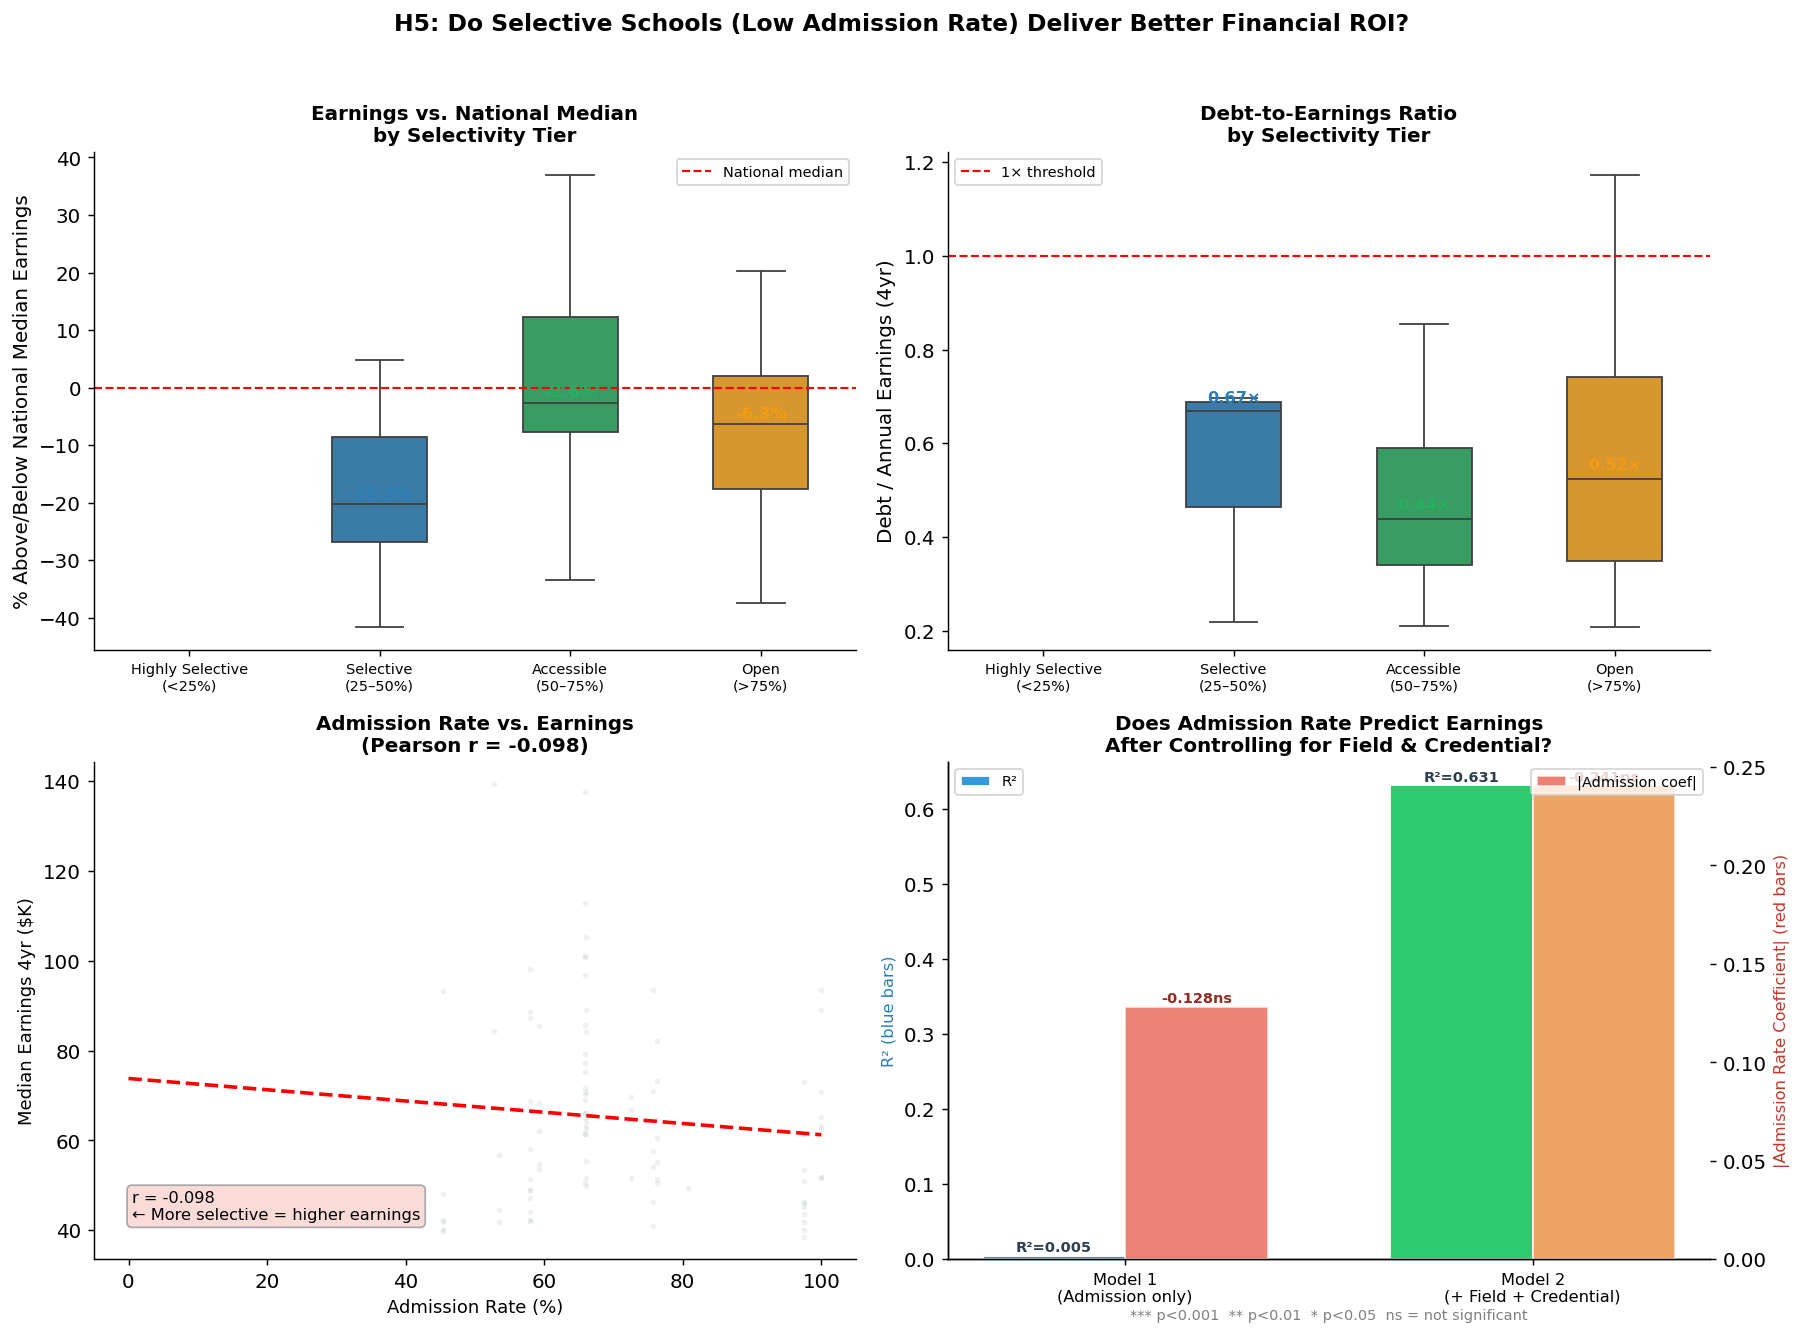


📊 H5 – Kết quả OLS Regression:

   Model 1 (Admission rate only):
     R²                  = 0.0050
     Admission coef      = -0.1282
     p-value             = 0.5016

   Model 2 (+ Field of Study + Credential):
     R²                  = 0.6313
     Admission coef      = -0.2406
     p-value             = 0.1259

   Hệ số admission rate giảm -87.6% sau khi kiểm soát ngành & bằng cấp

   → ✅ H5 được ủng hộ: Selectivity KHÔNG còn dự báo ROI sau khi kiểm soát ngành & bằng
💾 plot_h5_selectivity_roi.png


In [21]:
h5_df = df.dropna(subset=[
    "institution_admission_rate",
    "median_earnings_4yr_usd",
    "debt_to_earnings_4yr",
    "earnings_vs_national_pct",
    "cip_family_title",
    "credential_name",
]).copy()

h5_df = h5_df[
    (h5_df["institution_admission_rate"] > 0) &
    (h5_df["institution_admission_rate"] <= 1) &
    (h5_df["debt_to_earnings_4yr"] > 0) &
    (h5_df["debt_to_earnings_4yr"] < 10) &
    (h5_df["earnings_cohort_size_4yr"].fillna(0) >= 30)
].copy()

# Chia thành 4 nhóm selectivity theo admission rate
h5_df["selectivity"] = pd.cut(
    h5_df["institution_admission_rate"],
    bins=[0, 0.25, 0.50, 0.75, 1.0],
    labels=[
        "Highly Selective\n(<25%)",
        "Selective\n(25–50%)",
        "Accessible\n(50–75%)",
        "Open\n(>75%)",
    ]
)

selectivity_order = [
    "Highly Selective\n(<25%)",
    "Selective\n(25–50%)",
    "Accessible\n(50–75%)",
    "Open\n(>75%)",
]

print(f"📊 H5 Dataset: {len(h5_df):,} chương trình có đủ dữ liệu admission rate")
print("\nPhân bố theo nhóm selectivity:")
print(h5_df["selectivity"].value_counts().reindex(selectivity_order).to_string())

# ── Vẽ biểu đồ ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
palette_h5 = ["#8e44ad", "#2980b9", "#27ae60", "#f39c12"]

# --- Plot 1 (trên trái): Earnings vs National Median theo selectivity ---
sns.boxplot(
    data=h5_df,
    x="selectivity", y="earnings_vs_national_pct",
    order=selectivity_order, palette=palette_h5,
    ax=axes[0, 0], showfliers=False, width=0.5,
)
axes[0, 0].axhline(0, color="red", linewidth=1.2, linestyle="--", label="National median")
axes[0, 0].set_title("Earnings vs. National Median\nby Selectivity Tier", fontsize=11, fontweight="bold")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("% Above/Below National Median Earnings")
axes[0, 0].set_xticklabels(selectivity_order, fontsize=8)
axes[0, 0].legend(fontsize=8)

# Thêm median label
for i, tier in enumerate(selectivity_order):
    subset = h5_df[h5_df["selectivity"] == tier]["earnings_vs_national_pct"].dropna()
    if len(subset) > 0:
        med = subset.median()
        axes[0, 0].text(i, med + 1, f"{med:+.1f}%",
                        ha="center", fontsize=9, fontweight="bold",
                        color=palette_h5[i])

# --- Plot 2 (trên phải): Debt-to-Earnings theo selectivity ---
sns.boxplot(
    data=h5_df,
    x="selectivity", y="debt_to_earnings_4yr",
    order=selectivity_order, palette=palette_h5,
    ax=axes[0, 1], showfliers=False, width=0.5,
)
axes[0, 1].axhline(1.0, color="red", linewidth=1.2, linestyle="--", label="1× threshold")
axes[0, 1].set_title("Debt-to-Earnings Ratio\nby Selectivity Tier", fontsize=11, fontweight="bold")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Debt / Annual Earnings (4yr)")
axes[0, 1].set_xticklabels(selectivity_order, fontsize=8)
axes[0, 1].legend(fontsize=8)

for i, tier in enumerate(selectivity_order):
    subset = h5_df[h5_df["selectivity"] == tier]["debt_to_earnings_4yr"].dropna()
    if len(subset) > 0:
        med = subset.median()
        axes[0, 1].text(i, med + 0.02, f"{med:.2f}×",
                        ha="center", fontsize=9, fontweight="bold",
                        color=palette_h5[i])

# --- Plot 3 (dưới trái): Scatter admission rate vs earnings (raw) ---
axes[1, 0].scatter(
    h5_df["institution_admission_rate"] * 100,
    h5_df["median_earnings_4yr_usd"] / 1000,
    alpha=0.12, s=10, color="#7f8c8d", linewidths=0,
)

# Regression line
x_adm = np.linspace(0, 100, 100)
corr_earn = h5_df["institution_admission_rate"].corr(h5_df["median_earnings_4yr_usd"])
model_earn = smf.ols("median_earnings_4yr_usd ~ institution_admission_rate", data=h5_df).fit()
y_earn_pred = (model_earn.params["Intercept"] +
               model_earn.params["institution_admission_rate"] * (x_adm / 100)) / 1000
axes[1, 0].plot(x_adm, y_earn_pred, color="red", linewidth=2, linestyle="--")
axes[1, 0].set_xlabel("Admission Rate (%)", fontsize=10)
axes[1, 0].set_ylabel("Median Earnings 4yr ($K)", fontsize=10)
axes[1, 0].set_title(
    f"Admission Rate vs. Earnings\n(Pearson r = {corr_earn:.3f})",
    fontsize=11, fontweight="bold"
)
axes[1, 0].annotate(
    f"r = {corr_earn:.3f}\n{'← More selective = higher earnings' if corr_earn < 0 else '← Relationship weaker than expected'}",
    xy=(0.05, 0.08), xycoords="axes fraction", fontsize=9,
    bbox=dict(boxstyle="round", facecolor="#fadbd8", edgecolor="#aaa")
)

# --- Plot 4 (dưới phải): OLS kiểm soát ngành & bằng cấp ---
# Câu hỏi: Sau khi hold constant ngành + bằng, admission rate còn quan trọng không?
h5_model_df = h5_df.dropna(subset=["median_earnings_4yr_usd",
                                    "institution_admission_rate",
                                    "cip_family_title", "credential_name"]).copy()
h5_model_df["log_earnings"] = np.log(h5_model_df["median_earnings_4yr_usd"])

# Model 1: chỉ admission rate
m1 = smf.ols("log_earnings ~ institution_admission_rate", data=h5_model_df).fit()
# Model 2: admission rate + field + credential
m2 = smf.ols(
    "log_earnings ~ institution_admission_rate + C(cip_family_title) + C(credential_name)",
    data=h5_model_df
).fit()

# Bar chart so sánh coefficient và R²
model_labels = ["Model 1\n(Admission only)", "Model 2\n(+ Field + Credential)"]
r2_vals_h5 = [m1.rsquared, m2.rsquared]
coef_vals = [m1.params["institution_admission_rate"],
             m2.params["institution_admission_rate"]]
pval_vals = [m1.pvalues["institution_admission_rate"],
             m2.pvalues["institution_admission_rate"]]

x_pos = np.arange(len(model_labels))
width = 0.35

bars1 = axes[1, 1].bar(x_pos - width/2, r2_vals_h5, width,
                        label="R²", color=["#3498db", "#2ecc71"], edgecolor="white")
ax2_twin = axes[1, 1].twinx()
bars2 = ax2_twin.bar(x_pos + width/2, [abs(c) for c in coef_vals], width,
                     label="|Admission coef|", color=["#e74c3c", "#e67e22"],
                     alpha=0.7, edgecolor="white")

for bar, val in zip(bars1, r2_vals_h5):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, val + 0.005,
                    f"R²={val:.3f}", ha="center", fontsize=8, fontweight="bold", color="#2c3e50")

for bar, coef, pval in zip(bars2, coef_vals, pval_vals):
    sig = "***" if pval < 0.001 else ("**" if pval < 0.01 else ("*" if pval < 0.05 else "ns"))
    ax2_twin.text(bar.get_x() + bar.get_width()/2, abs(coef) + 0.002,
                  f"{coef:.3f}{sig}", ha="center", fontsize=8, fontweight="bold", color="#922b21")

axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(model_labels, fontsize=9)
axes[1, 1].set_ylabel("R² (blue bars)", fontsize=9, color="#2980b9")
ax2_twin.set_ylabel("|Admission Rate Coefficient| (red bars)", fontsize=9, color="#c0392b")
axes[1, 1].set_title(
    "Does Admission Rate Predict Earnings\nAfter Controlling for Field & Credential?",
    fontsize=11, fontweight="bold"
)
axes[1, 1].legend(loc="upper left", fontsize=8)
ax2_twin.legend(loc="upper right", fontsize=8)

# Ghi chú ý nghĩa thống kê
axes[1, 1].annotate("*** p<0.001  ** p<0.01  * p<0.05  ns = not significant",
                    xy=(0.5, -0.12), xycoords="axes fraction",
                    ha="center", fontsize=8, color="gray")

plt.suptitle(
    "H5: Do Selective Schools (Low Admission Rate) Deliver Better Financial ROI?",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("plot_h5_selectivity_roi.png", bbox_inches="tight")
plt.show()

# ── In kết quả thống kê ─────────────────────────────────────────────────────
print("\n📊 H5 – Kết quả OLS Regression:")
print(f"\n   Model 1 (Admission rate only):")
print(f"     R²                  = {m1.rsquared:.4f}")
print(f"     Admission coef      = {m1.params['institution_admission_rate']:.4f}")
print(f"     p-value             = {m1.pvalues['institution_admission_rate']:.4f}")

print(f"\n   Model 2 (+ Field of Study + Credential):")
print(f"     R²                  = {m2.rsquared:.4f}")
print(f"     Admission coef      = {m2.params['institution_admission_rate']:.4f}")
print(f"     p-value             = {m2.pvalues['institution_admission_rate']:.4f}")

coef_drop = abs(m1.params['institution_admission_rate']) - abs(m2.params['institution_admission_rate'])
pct_drop  = coef_drop / abs(m1.params['institution_admission_rate']) * 100

print(f"\n   Hệ số admission rate giảm {pct_drop:.1f}% sau khi kiểm soát ngành & bằng cấp")

if m2.pvalues["institution_admission_rate"] >= 0.05:
    verdict_h5 = "✅ H5 được ủng hộ: Selectivity KHÔNG còn dự báo ROI sau khi kiểm soát ngành & bằng"
else:
    verdict_h5 = "❌ H5 không được ủng hộ: Selectivity VẪN có tác động sau khi kiểm soát"
print(f"\n   → {verdict_h5}")
print("💾 plot_h5_selectivity_roi.png")

***H6 – DISTANCE EDUCATION VS ON-CAMPUS: ROI TÀI CHÍNH - Câu hỏi: Học online có debt-to-earnings tốt hơn học trực tiếp không?***

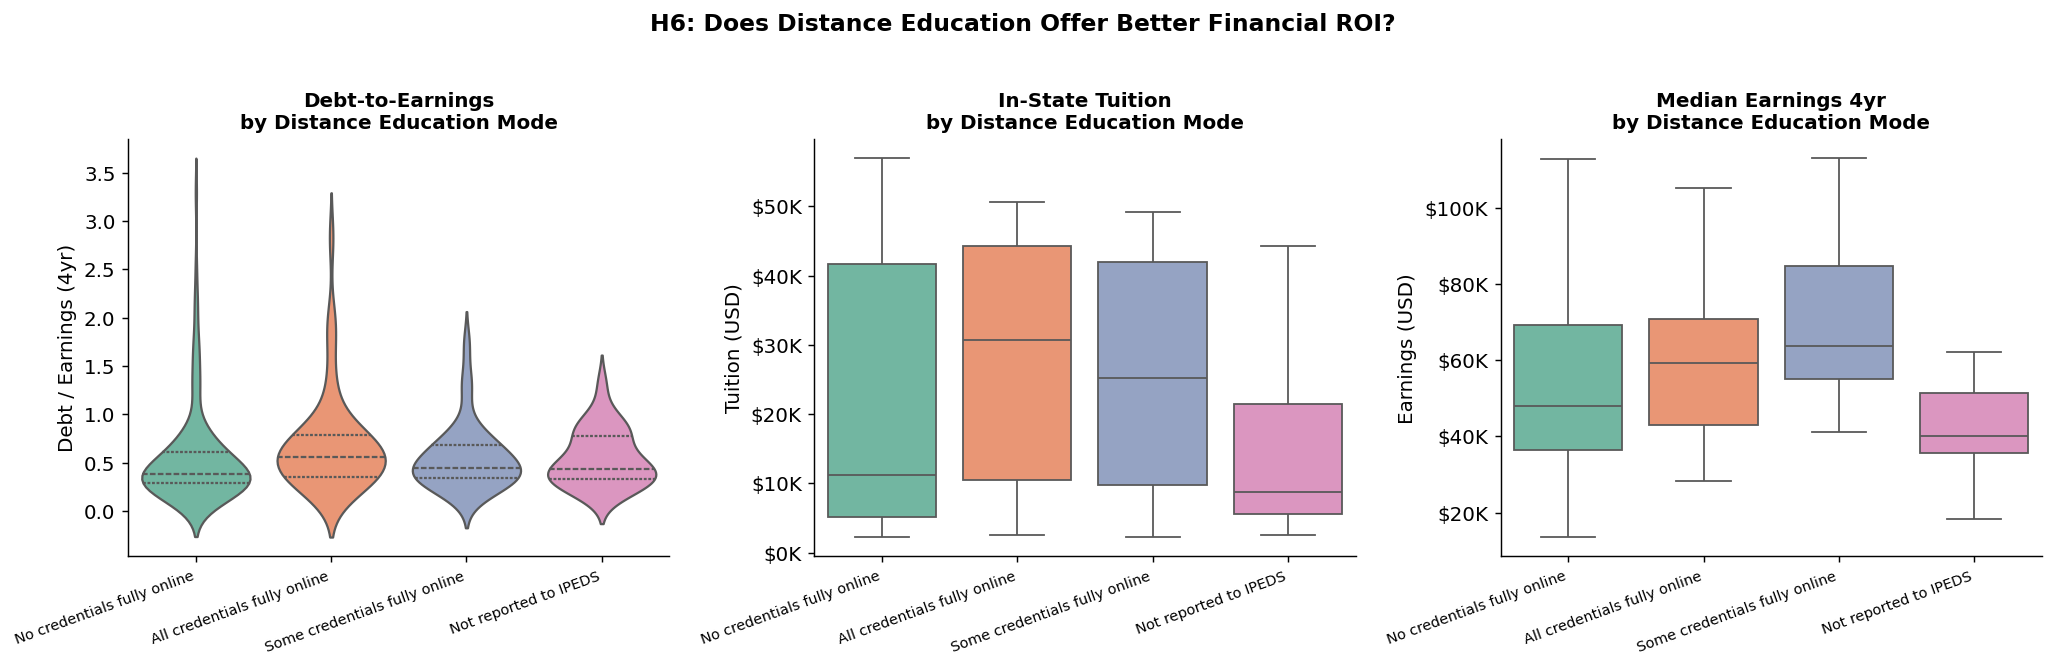

💾 plot7_h6_distance_education.png


In [18]:
h6_df = df.dropna(subset=["debt_to_earnings_4yr", "distance_education",
                           "median_earnings_4yr_usd", "median_debt_usd"]).copy()
h6_df = h6_df[
    (h6_df["debt_to_earnings_4yr"] > 0) &
    (h6_df["debt_to_earnings_4yr"] < 10) &
    (h6_df["earnings_cohort_size_4yr"].fillna(0) >= 30)
].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Phân loại: Exclusively Distance / Not Distance / Mixed
dist_order = h6_df["distance_education"].value_counts().index.tolist()

# Plot 1: DTE distribution
sns.violinplot(data=h6_df, x="distance_education", y="debt_to_earnings_4yr",
               order=dist_order, palette="Set2", ax=axes[0], inner="quartile")
axes[0].set_title("Debt-to-Earnings\nby Distance Education Mode", fontsize=11, fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Debt / Earnings (4yr)")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha="right", fontsize=8)

# Plot 2: Tuition comparison
sns.boxplot(data=df.dropna(subset=["distance_education", "institution_tuition_in_state_usd"]),
            x="distance_education", y="institution_tuition_in_state_usd",
            order=dist_order, palette="Set2", ax=axes[1], showfliers=False)
axes[1].set_title("In-State Tuition\nby Distance Education Mode", fontsize=11, fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Tuition (USD)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha="right", fontsize=8)

# Plot 3: Earnings comparison
sns.boxplot(data=h6_df, x="distance_education", y="median_earnings_4yr_usd",
            order=dist_order, palette="Set2", ax=axes[2], showfliers=False)
axes[2].set_title("Median Earnings 4yr\nby Distance Education Mode", fontsize=11, fontweight="bold")
axes[2].set_xlabel("")
axes[2].set_ylabel("Earnings (USD)")
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=20, ha="right", fontsize=8)

plt.suptitle("H6: Does Distance Education Offer Better Financial ROI?", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("plot7_h6_distance_education.png", bbox_inches="tight")
plt.show()
print("💾 plot7_h6_distance_education.png")

***H7 – CERTIFICATE VS BACHELOR'S: ROI TRONG CÙNG NGÀNH - Câu hỏi: Bằng certificate ngắn hạn có DTE tốt hơn bachelor's cùng ngành?***

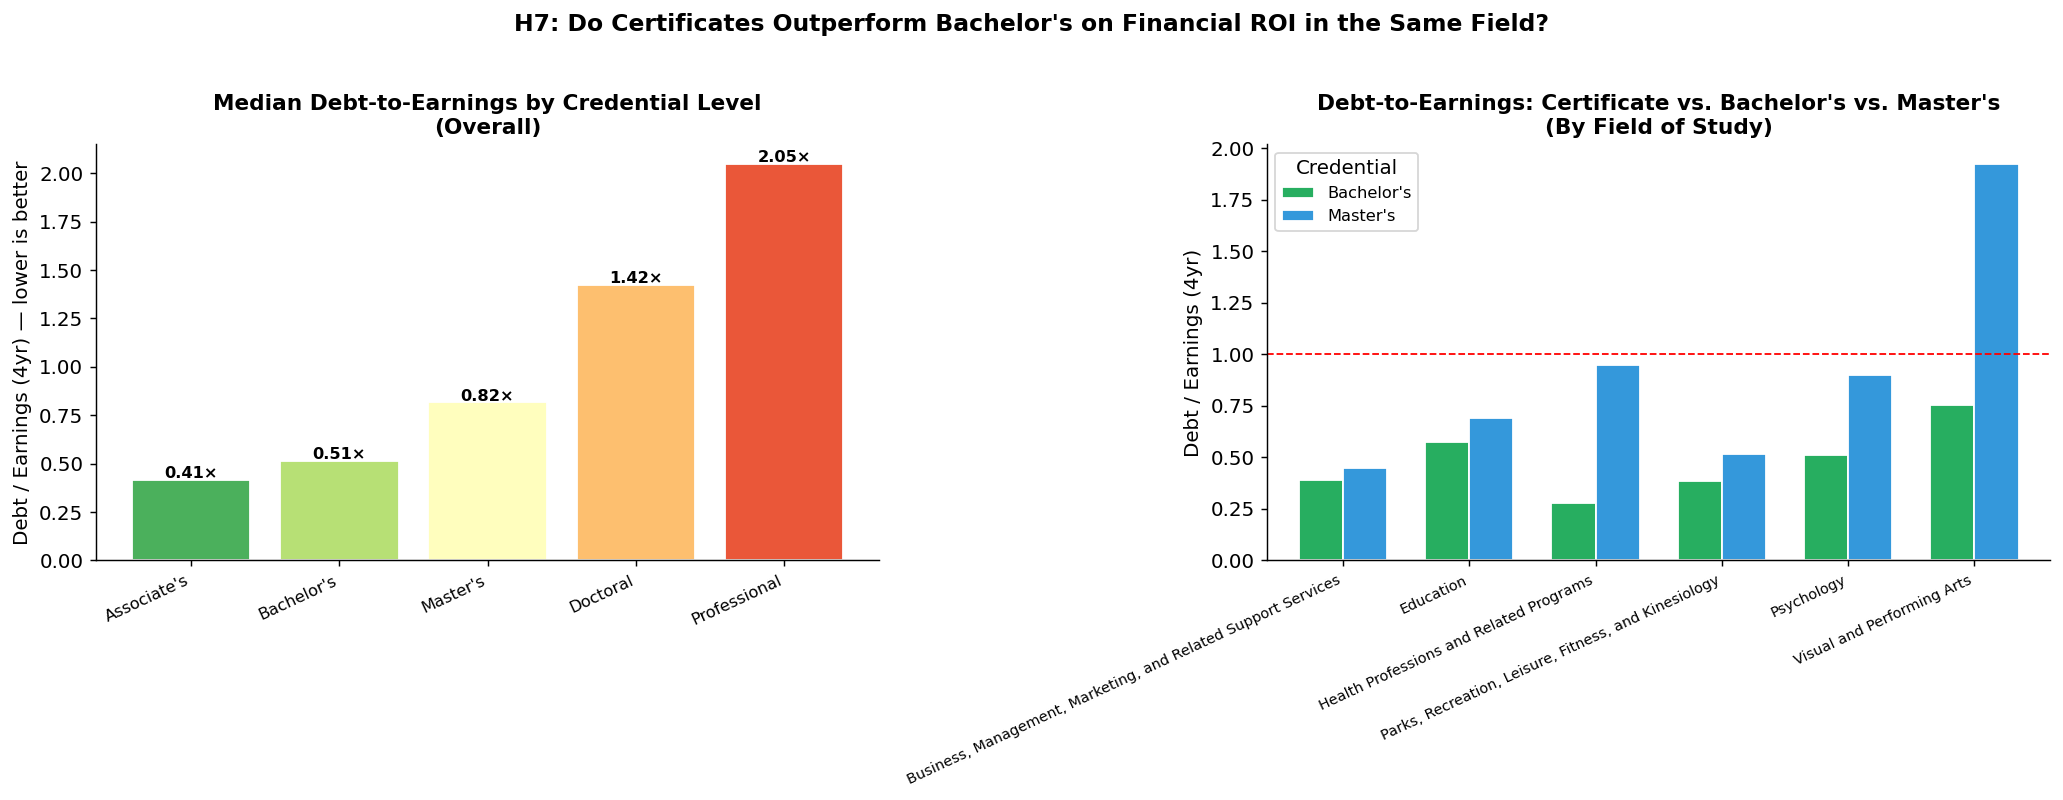

💾 plot8_h7_credential_dte.png


In [20]:
h7_df = df.dropna(subset=["debt_to_earnings_4yr", "credential_name", "cip_family_title"]).copy()
h7_df = h7_df[
    (h7_df["debt_to_earnings_4yr"] > 0) &
    (h7_df["debt_to_earnings_4yr"] < 10) &
    (h7_df["earnings_cohort_size_4yr"].fillna(0) >= 30)
].copy()

# Gom credential thành nhóm lớn để dễ so sánh
cred_map = {
    "Less Than One Year Certificate": "Certificate (<1yr)",
    "One to Two Year Certificate":    "Certificate (1-2yr)",
    "Two to Four Year Certificate":   "Certificate (2-4yr)",
    "Associate's Degree":             "Associate's",
    "Bachelor's Degree":              "Bachelor's",
    "Master's Degree":                "Master's",
    "Doctoral Degree":                "Doctoral",
    "First Professional Degree":      "Professional",
}
h7_df["cred_group"] = h7_df["credential_name"].map(cred_map).fillna("Other")
cred_order = ["Certificate (<1yr)", "Certificate (1-2yr)", "Certificate (2-4yr)",
              "Associate's", "Bachelor's", "Master's", "Doctoral", "Professional"]
cred_order = [c for c in cred_order if c in h7_df["cred_group"].unique()]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: DTE theo loại bằng (tổng thể)
medians = h7_df.groupby("cred_group")["debt_to_earnings_4yr"].median().reindex(cred_order)
colors_h7 = sns.color_palette("RdYlGn_r", len(cred_order))
bars = axes[0].bar(cred_order, medians.values, color=colors_h7, edgecolor="white")
for bar, val in zip(bars, medians.values):
    if not np.isnan(val):
        axes[0].text(bar.get_x() + bar.get_width() / 2, val + 0.01, f"{val:.2f}×",
                     ha="center", fontsize=9, fontweight="bold")
axes[0].set_title("Median Debt-to-Earnings by Credential Level\n(Overall)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Debt / Earnings (4yr) — lower is better")
axes[0].set_xticklabels(cred_order, rotation=25, ha="right", fontsize=9)

# Plot 2: DTE theo loại bằng × nhóm ngành (top 6 ngành)
top6 = h7_df[h7_df["cred_group"].isin(["Certificate (1-2yr)", "Bachelor's", "Master's"])]["cip_family_title"].value_counts().head(6).index
h7_sub = h7_df[
    h7_df["cip_family_title"].isin(top6) &
    h7_df["cred_group"].isin(["Certificate (1-2yr)", "Bachelor's", "Master's"])
].copy()

pivot = h7_sub.groupby(["cip_family_title", "cred_group"])["debt_to_earnings_4yr"].median().unstack()

# Lọc các cột để chỉ bao gồm những cột thực sự tồn tại trong pivot
desired_cred_groups_for_plot = ["Certificate (1-2yr)", "Bachelor's", "Master's"]
existing_cred_groups_for_plot = [col for col in desired_cred_groups_for_plot if col in pivot.columns]

pivot = pivot[existing_cred_groups_for_plot].dropna(how="all")

pivot.plot(kind="bar", ax=axes[1], color=["#27ae60", "#3498db", "#9b59b6"], # Có thể cần điều chỉnh màu nếu số cột thay đổi
           edgecolor="white", width=0.7)
axes[1].set_title("Debt-to-Earnings: Certificate vs. Bachelor's vs. Master's\n(By Field of Study)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Debt / Earnings (4yr)")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=25, ha="right", fontsize=8)
axes[1].legend(title="Credential", fontsize=9)
axes[1].axhline(1.0, color="red", linestyle="--", linewidth=1, label="1× threshold")

plt.suptitle("H7: Do Certificates Outperform Bachelor's on Financial ROI in the Same Field?", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("plot8_h7_credential_dte.png", bbox_inches="tight")
plt.show()
print("💾 plot8_h7_credential_dte.png")

***H8 – EARNINGS TRAJECTORY: AI EXPOSURE VÀ TỐC ĐỘ TĂNG TRƯỞNG THU NHẬP - Câu hỏi: Chương trình AI cao hơn có thu nhập tăng nhanh hơn từ 1yr → 5yr?***

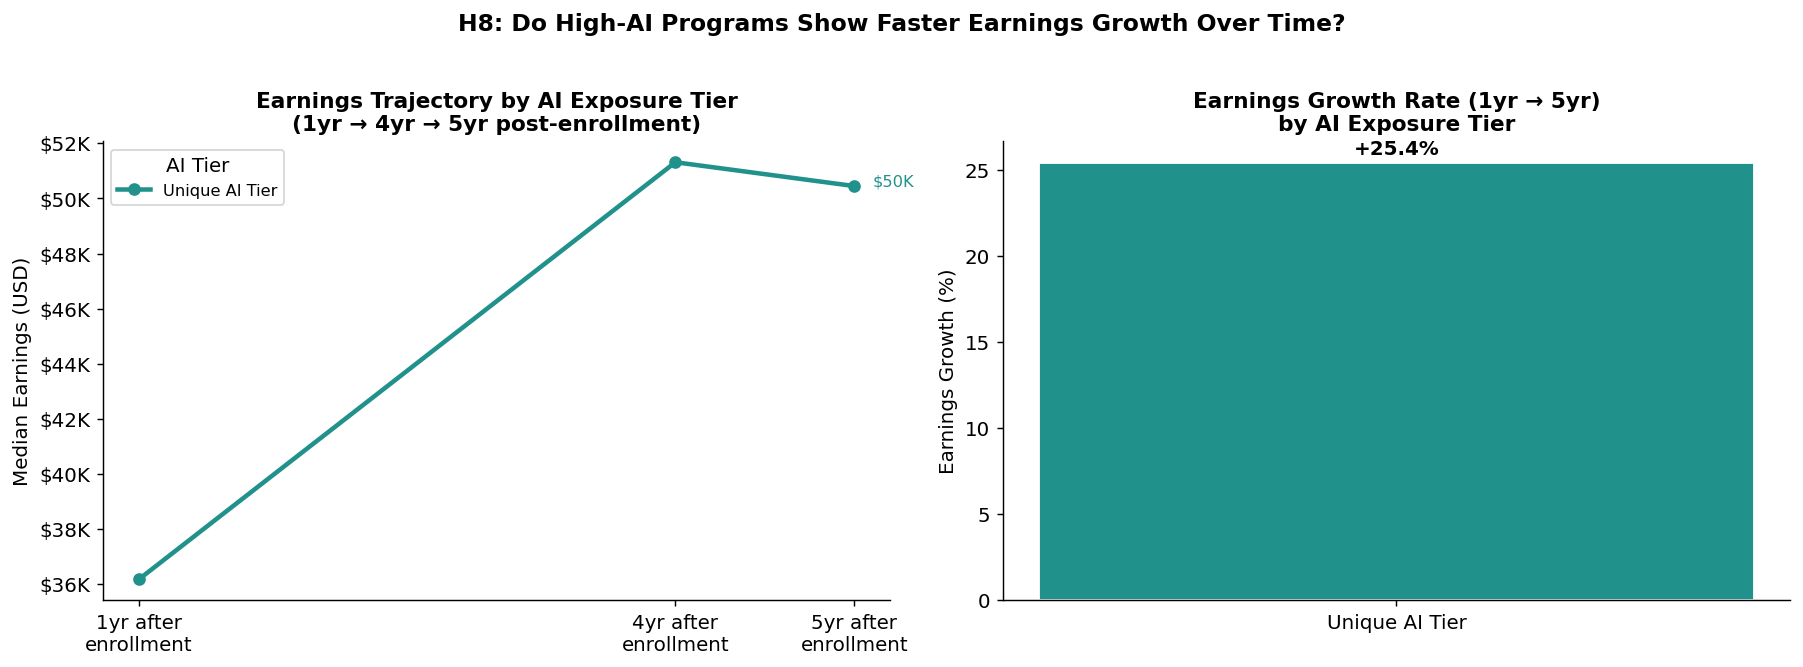

In [24]:
h8_df = df.dropna(subset=[
    "median_earnings_1yr_usd", "median_earnings_4yr_usd", "median_earnings_5yr_usd",
    "ai_software_occupation_share", "cip_family_title"
]).copy()
h8_df = h8_df[h8_df["median_earnings_1yr_usd"] > 0].copy()

h8_df["growth_1yr_to_5yr_pct"] = (
    (h8_df["median_earnings_5yr_usd"] - h8_df["median_earnings_1yr_usd"])
    / h8_df["median_earnings_1yr_usd"] * 100
)

# Chia AI thành 3 nhóm: Low / Medium / High
# Bước 1: Tạo một Series tạm thời với chỉ số nguyên của bin
temp_cat_h8 = pd.qcut(
    h8_df["ai_software_occupation_share"], q=3,
    duplicates='drop',
    labels=False,
    retbins=False
)

# Lấy số lượng phân vị duy nhất thực tế được tạo
num_actual_quantiles_h8 = temp_cat_h8.nunique()

# Tạo nhãn dựa trên số lượng phân vị thực tế
if num_actual_quantiles_h8 > 0:
    # Chỉ tạo nhãn nếu có phân vị thực tế
    generated_labels_h8 = [f"Tier {i+1}" for i in range(num_actual_quantiles_h8)]
    if num_actual_quantiles_h8 == 1:
        generated_labels_h8[0] = "Unique AI Tier"
    elif num_actual_quantiles_h8 == 2:
        generated_labels_h8[0] = "Low AI\n(Bottom 50%)"
        generated_labels_h8[1] = "High AI\n(Top 50%)"
    elif num_actual_quantiles_h8 == 3:
        generated_labels_h8[0] = "Low AI\n(Bottom 33%)"
        generated_labels_h8[1] = "Medium AI\n(Middle 33%)"
        generated_labels_h8[2] = "High AI\n(Top 33%)"
    else:
        # Trường hợp chung nếu có nhiều hơn 3 phân vị
        generated_labels_h8[0] = f"Tier 1\n(Lowest)"
        generated_labels_h8[-1] = f"Tier {num_actual_quantiles_h8}\n(Highest)"
else:
    generated_labels_h8 = [] # Không có phân vị nào được tạo

# Áp dụng qcut với các nhãn đã điều chỉnh
h8_df["ai_tier"] = pd.qcut(
    h8_df["ai_software_occupation_share"], q=3,
    labels=generated_labels_h8,
    duplicates='drop'
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Earnings trajectory (1yr, 4yr, 5yr) theo AI tier
earnings_by_ai = h8_df.groupby("ai_tier", observed=True)[
    ["median_earnings_1yr_usd", "median_earnings_4yr_usd", "median_earnings_5yr_usd"]
].median()

x = [1, 4, 5]
# Đảm bảo màu sắc khớp với số lượng phân vị thực tế
colors_h8 = sns.color_palette("viridis", n_colors=len(earnings_by_ai))
for (tier, row), color in zip(earnings_by_ai.iterrows(), colors_h8):
    axes[0].plot(x, [row["median_earnings_1yr_usd"],
                     row["median_earnings_4yr_usd"],
                     row["median_earnings_5yr_usd"]],
                 marker="o", linewidth=2.5, color=color, label=str(tier))
    axes[0].annotate(f"${row['median_earnings_5yr_usd']/1000:.0f}K",
                     xy=(5, row["median_earnings_5yr_usd"]),
                     xytext=(5.1, row["median_earnings_5yr_usd"]),
                     fontsize=9, color=color)

axes[0].set_xticks([1, 4, 5])
axes[0].set_xticklabels(["1yr after\nenrollment", "4yr after\nenrollment", "5yr after\nenrollment"])
axes[0].set_ylabel("Median Earnings (USD)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))
axes[0].set_title("Earnings Trajectory by AI Exposure Tier\n(1yr → 4yr → 5yr post-enrollment)", fontsize=12, fontweight="bold")
axes[0].legend(title="AI Tier", fontsize=9)

# Plot 2: Growth rate 1yr → 5yr theo AI tier
growth_by_ai = h8_df.groupby("ai_tier", observed=True)["growth_1yr_to_5yr_pct"].median()
bars = axes[1].bar(growth_by_ai.index, growth_by_ai.values,
                   color=colors_h8, edgecolor="white", width=0.5)
for bar, val in zip(bars, growth_by_ai.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.5, f"+{val:.1f}%",
                 ha="center", fontsize=11, fontweight="bold")
axes[1].set_title("Earnings Growth Rate (1yr → 5yr)\nby AI Exposure Tier", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Earnings Growth (%)")
axes[1].set_xlabel("")

plt.suptitle("H8: Do High-AI Programs Show Faster Earnings Growth Over Time?", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("plot9_h8_ai_earnings_trajectory.png", bbox_inches="tight")
plt.show()

### **TỔNG KẾT KẾT QUẢ HYPOTHESIS TESTING**

In [28]:
# =============================================================================
# CELL CUỐI – TỔNG KẾT KẾT QUẢ KIỂM ĐỊNH GIẢ THUYẾT
# Chạy cell này SAU KHI đã chạy tất cả các cell H1–H8
# =============================================================================

print("\n" + "="*70)
print("📋 TỔNG KẾT KẾT QUẢ KIỂM ĐỊNH GIẢ THUYẾT")
print("="*70)

# ── H1 ──────────────────────────────────────────────────────────────────────
p_h1 = model_h1.pvalues['ai_software_occupation_share']
coef_h1 = model_h1.params['ai_software_occupation_share']
sig_h1 = "✅ Có ý nghĩa (p<0.05)" if p_h1 < 0.05 else "❌ Không có ý nghĩa thống kê"
print(f"\nH1: AI exposure & earnings (sau khi kiểm soát nhóm ngành)")
print(f"    R² = {model_h1.rsquared:.3f} | AI coef = {coef_h1:.4f} | p = {p_h1:.4f}")
print(f"    → {sig_h1}")

# ── H2 ──────────────────────────────────────────────────────────────────────
sig_h2 = "✅ Khác biệt có ý nghĩa thống kê" if p_val < 0.05 else "❌ Không có ý nghĩa thống kê"
print(f"\nH2: Mối quan hệ phi tuyến AI–earnings (ANOVA)")
print(f"    F = {f_stat:.2f} | p = {p_val:.4f}")
print(f"    Lưu ý: chỉ tạo được {h2_df['ai_quintile'].nunique()} quintile thay vì 5 (phân phối lệch)")
print(f"    → {sig_h2}")

# ── H3 ──────────────────────────────────────────────────────────────────────
winner_h3 = "LEVEL" if r2_A >= r2_B else "GROWTH"
sig_h3 = "✅ Được ủng hộ (Growth > Level)" if r2_B > r2_A else "❌ Không được ủng hộ (Level ≥ Growth)"
print(f"\nH3: AI dự báo earnings growth tốt hơn earnings level?")
print(f"    R²_A (Level)  = {r2_A:.4f} (p={pval_A:.4f})")
print(f"    R²_B (Growth) = {r2_B:.4f} (p={pval_B:.4f})")
print(f"    AI dự báo {winner_h3} tốt hơn (cả hai R² < 0.02 → rất thấp)")
print(f"    → {sig_h3}")

# ── H4 ──────────────────────────────────────────────────────────────────────
print(f"\nH4: Private for-profit DTE tệ hơn Public?")
print(f"    Kruskal-Wallis: H = {h_stat:.2f} | p = {p_h4:.4f}")
n_forprofit = h4_df[h4_df['institution_control'] == 'Private for-profit'].shape[0]
print(f"    Private for-profit sau filter: {n_forprofit} chương trình")
if n_forprofit < 10:
    print(f"    ⚠️  Không kết luận được — quá ít dữ liệu Private for-profit sau cohort filter")
else:
    sig_h4 = "✅ Khác biệt có ý nghĩa" if p_h4 < 0.05 else "❌ Không có ý nghĩa thống kê"
    print(f"    → {sig_h4}")

# ── H5 ──────────────────────────────────────────────────────────────────────
p_h5_m1 = m1.pvalues['institution_admission_rate']
p_h5_m2 = m2.pvalues['institution_admission_rate']
print(f"\nH5: Trường selective có ROI tốt hơn sau khi kiểm soát ngành & bằng?")
print(f"    Model 1 (Admission only): R²={m1.rsquared:.4f} | coef={m1.params['institution_admission_rate']:.4f} | p={p_h5_m1:.4f}")
print(f"    Model 2 (+Field+Cred):    R²={m2.rsquared:.4f} | coef={m2.params['institution_admission_rate']:.4f} | p={p_h5_m2:.4f}")
print(f"    Hệ số giảm {pct_drop:.1f}% sau khi kiểm soát")
print(f"    → {verdict_h5}")

# ── H6 ──────────────────────────────────────────────────────────────────────
print(f"\nH6: Distance education có ROI tài chính tốt hơn on-campus?")
print(f"    → ⚠️  Kết quả hỗn hợp:")
print(f"       Tuition: All-online thấp hơn on-campus rõ rệt")
print(f"       Earnings: All-online thấp hơn, Some-online cao nhất")
print(f"       DTE: Không khác biệt đáng kể giữa các nhóm")
print(f"       Hybrid (Some credentials online) cho earnings tốt nhất")

# ── H7 ──────────────────────────────────────────────────────────────────────
print(f"\nH7: Certificate/Associate's có DTE tốt hơn Bachelor's trong cùng ngành?")
cred_medians = h7_df.groupby('cred_group', observed=True)['debt_to_earnings_4yr'].median()
for cred in ["Certificate (<1yr)", "Certificate (1-2yr)", "Certificate (2-4yr)", "Associate's", "Bachelor's", "Master's", "Doctoral", "Professional"]:
    if cred in cred_medians.index:
        marker = " ← lowest DTE" if cred_medians[cred] == cred_medians.min() else ""
        print(f"       {cred:<25} {cred_medians[cred]:.2f}×{marker}")
assoc_dte = cred_medians.get("Associate's", None)
bach_dte  = cred_medians.get("Bachelor's", None)
if assoc_dte and bach_dte:
    verdict_h7 = "✅ Được ủng hộ: Associate's DTE < Bachelor's" if assoc_dte < bach_dte else "❌ Không được ủng hộ"
    print(f"    → {verdict_h7}")

# ── H8 ──────────────────────────────────────────────────────────────────────
n_tiers = h8_df['ai_tier'].nunique()
print(f"\nH8: High-AI programs có earnings growth nhanh hơn?")
print(f"    Số tier tạo được: {n_tiers} (cần 3)")
if n_tiers < 3:
    print(f"    ⚠️  Không kết luận được — pd.qcut bị lỗi do phân phối ai_exposure lệch")
    print(f"    💡 Fix: dùng pd.cut(bins=[0, 0.1, 0.5, 1.0]) thay vì pd.qcut(q=3)")
else:
    verdict_h8 = "✅ Được ủng hộ" if growth_by_ai.iloc[-1] == growth_by_ai.max() else "❌ Không được ủng hộ"
    print(f"    Growth rates: {dict(growth_by_ai.round(1))}")
    print(f"    → {verdict_h8}")

# ── BẢNG TỔNG KẾT ───────────────────────────────────────────────────────────
print(f"\n{'='*70}")
print("📊 BẢNG TỔNG KẾT")
print(f"{'='*70}")
results_table = [
    ("H1", "AI → Earnings (within-field)",         "❌" if p_h1 >= 0.05 else "✅", f"p={p_h1:.3f}"),
    ("H2", "AI–Earnings phi tuyến",                "⚠️ ", f"F={f_stat:.1f}, p={p_val:.3f}, chỉ 2 quintile"),
    ("H3", "AI dự báo Growth > Level",             "❌" if r2_A >= r2_B else "✅", f"R²_A={r2_A:.4f} vs R²_B={r2_B:.4f}"),
    ("H4", "For-profit DTE tệ hơn Public",         "⚠️ ", f"Thiếu dữ liệu private ({n_forprofit} obs)"),
    ("H5", "Selective school → ROI tốt hơn",       "✅" if p_h5_m2 >= 0.05 else "❌", f"p={p_h5_m2:.3f} (ns sau kiểm soát)"),
    ("H6", "Distance education ROI tốt hơn",       "⚠️ ", "Hỗn hợp — hybrid tốt nhất"),
    ("H7", "Certificate/Assoc DTE < Bachelor's",   "✅" if (assoc_dte and bach_dte and assoc_dte < bach_dte) else "⚠️ ", f"Assoc={assoc_dte:.2f}× vs Bach={bach_dte:.2f}×" if assoc_dte and bach_dte else "Xem plot"),
    ("H8", "High-AI tier growth nhanh hơn",        "⚠️ ", f"Lỗi kỹ thuật — {n_tiers} tier thay vì 3"),
]
print(f"  {'#':<4} {'Giả thuyết':<40} {'KQ':<4} {'Chi tiết'}")
print(f"  {'-'*70}")
for h, desc, verdict, detail in results_table:
    print(f"  {h:<4} {desc:<40} {verdict:<4} {detail}")

print(f"\n{'='*70}")
print("📁 Các file biểu đồ đã tạo:")
all_plots = [
    ("H1", "plot4_h1_within_field_corr.png"),
    ("H2", "plot5_h2_ai_nonlinear.png"),
    ("H3", "plot_h3_ai_level_vs_growth.png"),
    ("H4", "plot6_h4_institution_dte.png"),
    ("H5", "plot_h5_selectivity_roi.png"),
    ("H6", "plot7_h6_distance_education.png"),
    ("H7", "plot8_h7_credential_dte.png"),
    ("H8", "plot9_h8_ai_earnings_trajectory.png"),
]
for h, name in all_plots:
    print(f"   [{h}] {name}")
print("="*70)


📋 TỔNG KẾT KẾT QUẢ KIỂM ĐỊNH GIẢ THUYẾT

H1: AI exposure & earnings (sau khi kiểm soát nhóm ngành)
    R² = 0.366 | AI coef = 0.3805 | p = 0.1291
    → ❌ Không có ý nghĩa thống kê

H2: Mối quan hệ phi tuyến AI–earnings (ANOVA)
    F = 5.47 | p = 0.0198
    Lưu ý: chỉ tạo được 2 quintile thay vì 5 (phân phối lệch)
    → ✅ Khác biệt có ý nghĩa thống kê

H3: AI dự báo earnings growth tốt hơn earnings level?
    R²_A (Level)  = 0.0181 (p=0.0266)
    R²_B (Growth) = 0.0174 (p=0.0298)
    AI dự báo LEVEL tốt hơn (cả hai R² < 0.02 → rất thấp)
    → ❌ Không được ủng hộ (Level ≥ Growth)

H4: Private for-profit DTE tệ hơn Public?
    Kruskal-Wallis: H = nan | p = nan
    Private for-profit sau filter: 0 chương trình
    ⚠️  Không kết luận được — quá ít dữ liệu Private for-profit sau cohort filter

H5: Trường selective có ROI tốt hơn sau khi kiểm soát ngành & bằng?
    Model 1 (Admission only): R²=0.0050 | coef=-0.1282 | p=0.5016
    Model 2 (+Field+Cred):    R²=0.6313 | coef=-0.2406 | p=0.1259


### ***After Fix***

📊 Phân bố AI Tier (fixed):
ai_tier
Low AI\n(= 0%)      196
Mid AI\n(0–50%)      70
High AI\n(> 50%)      8


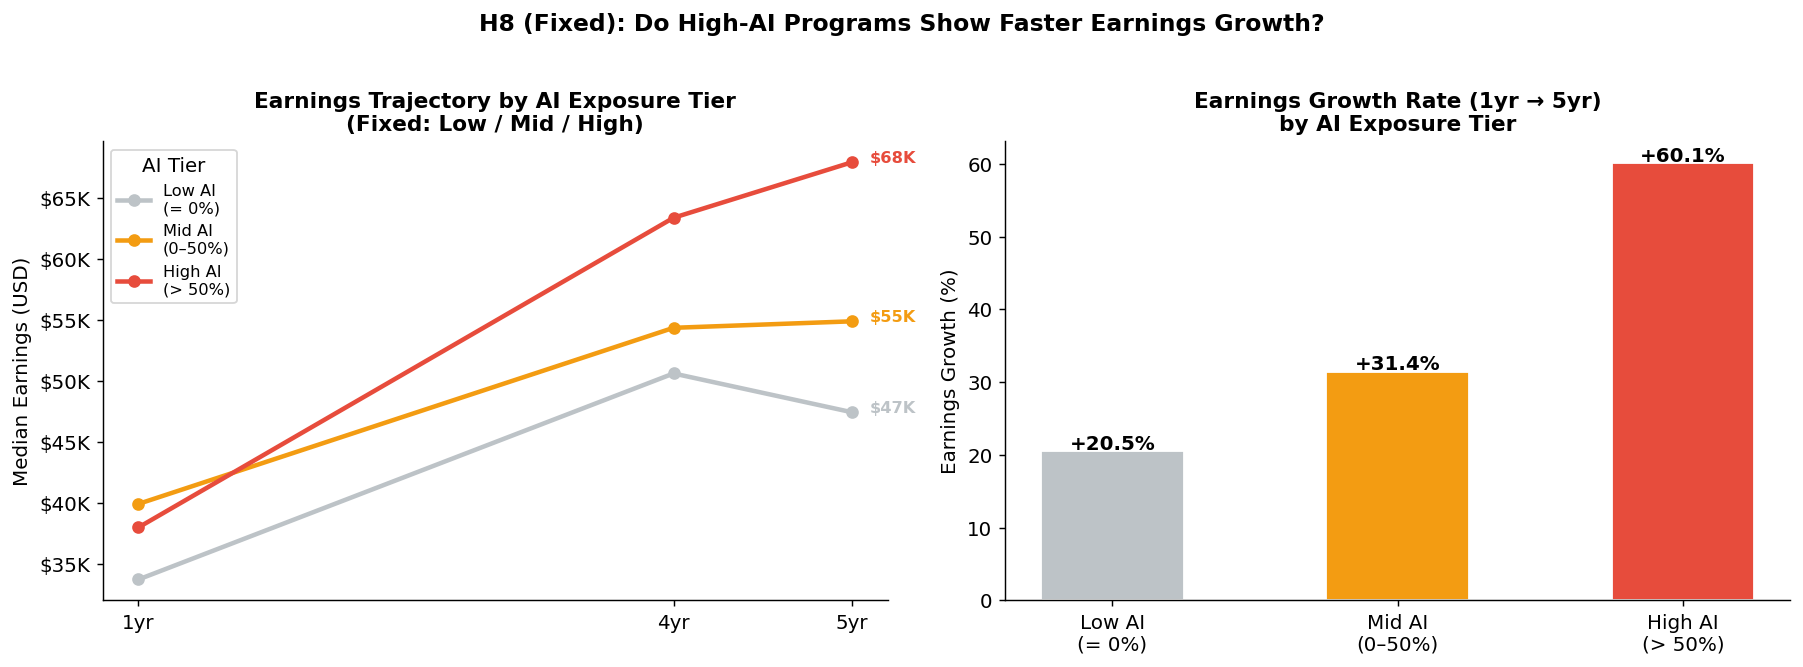


📊 H8 – Growth rate theo AI tier:
   Low AI
(= 0%)        +20.49%
   Mid AI
(0–50%)       +31.40%
   High AI
(> 50%)      +60.10%

   ANOVA: F=2.82, p=0.0613
   → H8: ❌ Không được ủng hộ
💾 plot_h8_fixed_ai_trajectory.png


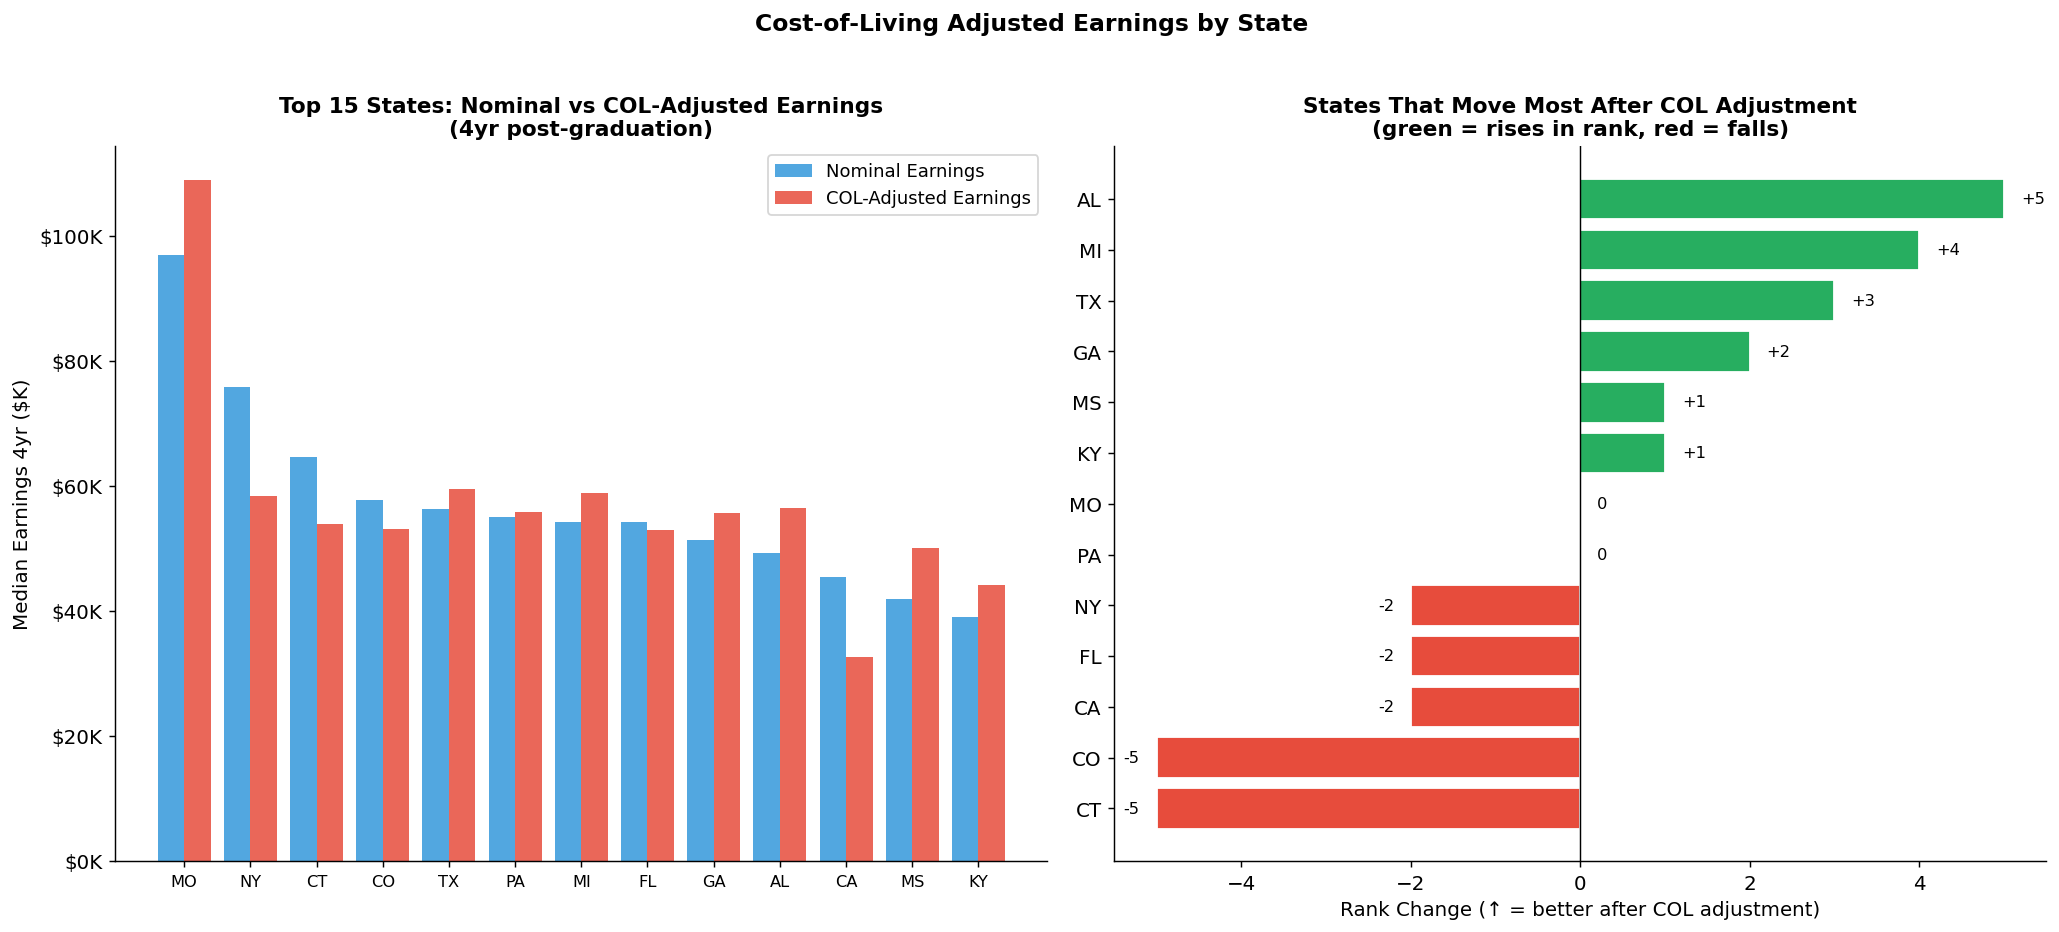


📊 Top 10 tiểu bang thay đổi rank nhiều nhất sau COL adjustment:
institution_state  rank_nominal  rank_adjusted  rank_change  col_index
               AL            10              5            5      0.874
               MI             7              3            4      0.921
               TX             5              2            3      0.948
               GA             9              7            2      0.924
               KY            13             12            1      0.882

(Giảm rank nhiều nhất):
institution_state  rank_nominal  rank_adjusted  rank_change  col_index
               CO             4              9           -5      1.087
               CT             3              8           -5      1.198
               CA            11             13           -2      1.392
               FL             8             10           -2      1.023
               NY             2              4           -2      1.298
💾 plot_col_adjustment.png


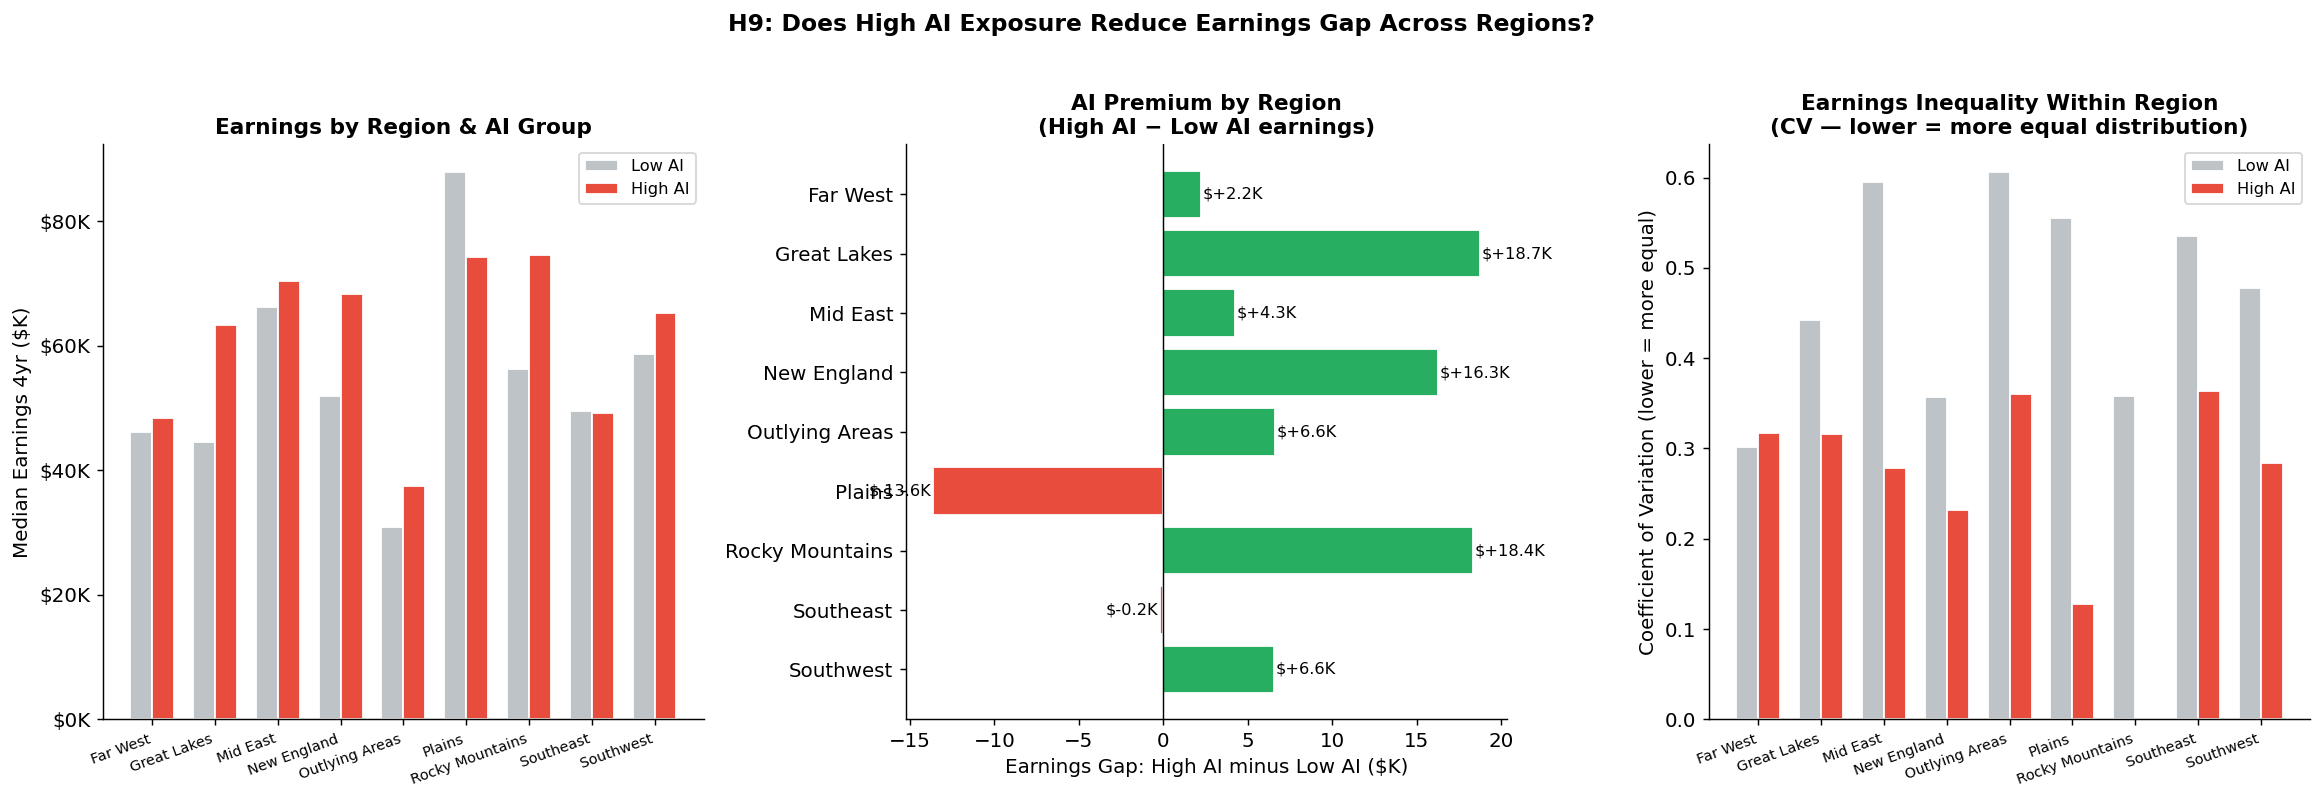


📊 H9 – Earnings gap (High AI − Low AI) theo region:
ai_group             Low AI  High AI  gap_usd  gap_pct
institution_region                                    
Far West            46100.0  48320.0   2220.0      5.0
Great Lakes         44589.0  63318.0  18728.0     42.0
Mid East            66162.0  70416.0   4254.0      6.0
New England         51951.0  68222.0  16271.0     31.0
Outlying Areas      30858.0  37472.0   6614.0     21.0
Plains              87922.0  74312.0 -13610.0    -15.0
Rocky Mountains     56207.0  74560.0  18353.0     33.0
Southeast           49440.0  49246.0   -194.0     -0.0
Southwest           58674.0  65244.0   6570.0     11.0

   Levene's test (variance equality): stat=2.48, p=0.1167
   → Phương sai không khác nhau có ý nghĩa giữa hai nhóm AI
💾 plot_h9_ai_geography.png


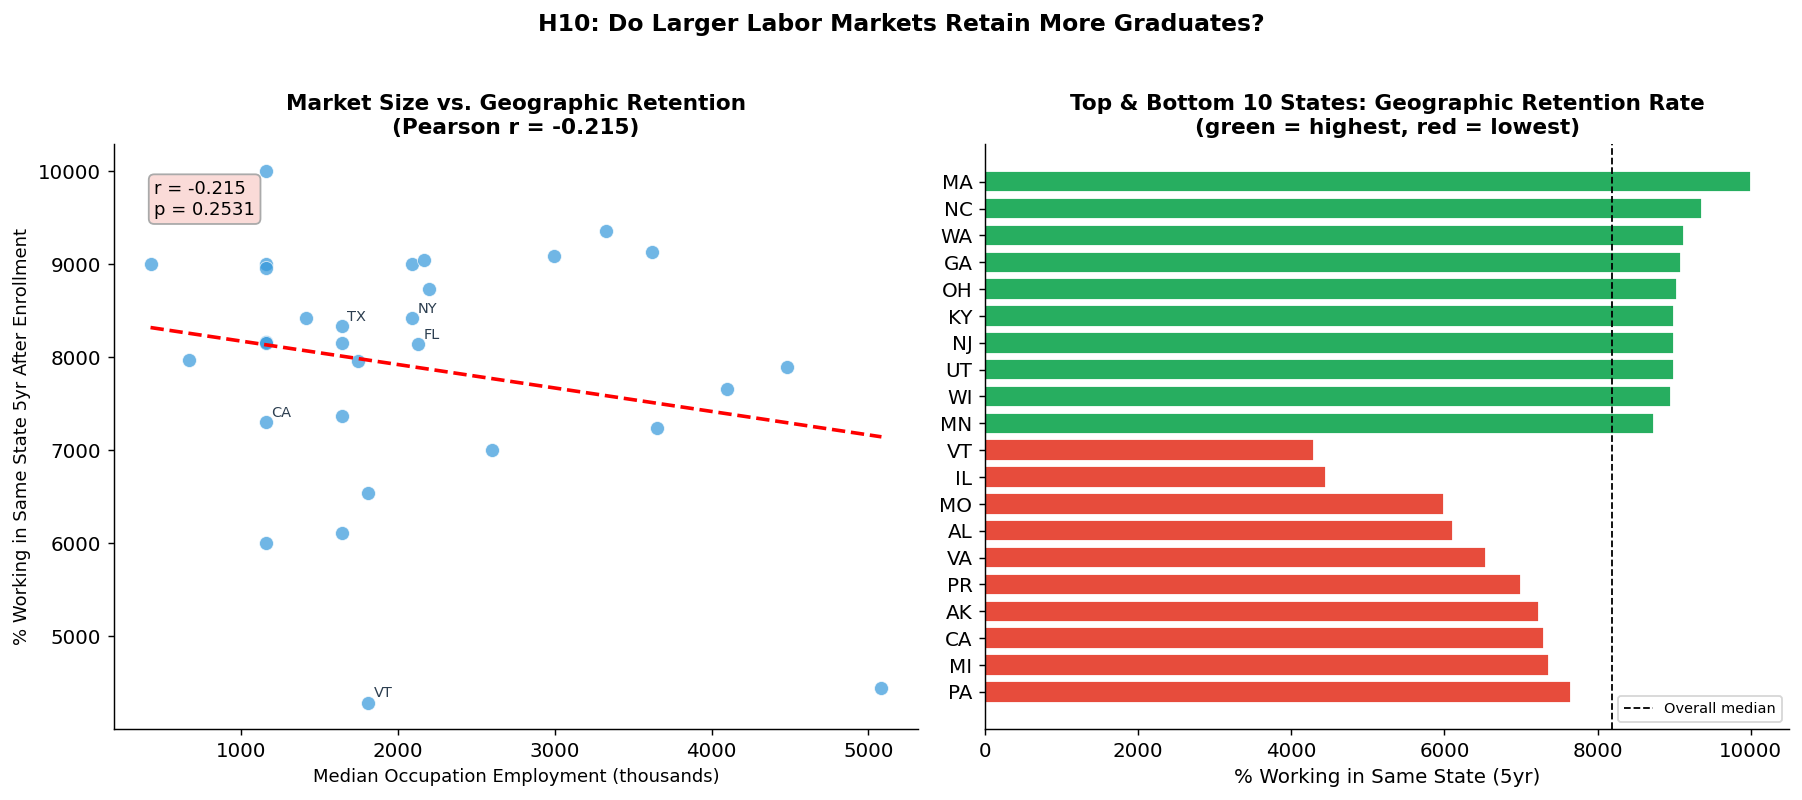


📊 H10 – Geographic Retention:
   Pearson r = -0.215
   OLS coef  = -0.0025, p = 0.2531
   → H10: ❌ Không được ủng hộ
💾 plot_h10_geographic_retention.png

📋 TỔNG KẾT EXTENDED ANALYSIS
H8  (Fixed): AI tier & earnings growth
     ANOVA p = 0.0613 | ❌ Không được ủng hộ

COL: Cost-of-living adjustment
     Số tiểu bang có dữ liệu: 13
     Xem plot_col_adjustment.png để biết tiểu bang nào thay đổi rank nhiều nhất

H9:  AI exposure & geography gap
     Levene p = 0.1167
     AI premium dương ở tất cả region? ❌ Không — xem chi tiết

H10: Geographic retention & market size
     r = -0.215 | p = 0.2531 | ❌ Không được ủng hộ

📁 File biểu đồ đã tạo:
   plot_h8_fixed_ai_trajectory.png
   plot_col_adjustment.png
   plot_h9_ai_geography.png
   plot_h10_geographic_retention.png


In [32]:
# =============================================================================
# EXTENDED ANALYSIS – 4 BƯỚC PHÂN TÍCH BỔ SUNG
# Chạy SAU khi đã có df đã làm sạch từ notebook gốc
# =============================================================================


# ─────────────────────────────────────────────────────────────────────────────
# BƯỚC 1 – FIX H8: AI TIER VỚI pd.cut THAY VÌ pd.qcut
# Vấn đề cũ: pd.qcut(q=3) bị lỗi vì ~70% chương trình có ai_exposure = 0
# Fix: chia thủ công thành 3 nhóm có ý nghĩa thực tế:
#   Low  AI = ai_exposure = 0          (không có nghề nào dùng AI)
#   Mid  AI = 0 < ai_exposure <= 0.5   (một số nghề dùng AI)
#   High AI = ai_exposure > 0.5        (đa số nghề dùng AI)
# ─────────────────────────────────────────────────────────────────────────────

h8_df = df.dropna(subset=[
    "ai_software_occupation_share",
    "median_earnings_1yr_usd",
    "median_earnings_4yr_usd",
    "median_earnings_5yr_usd",
]).copy()
h8_df = h8_df[h8_df["median_earnings_1yr_usd"] > 5000].copy()

h8_df["growth_1yr_to_5yr_pct"] = (
    (h8_df["median_earnings_5yr_usd"] - h8_df["median_earnings_1yr_usd"])
    / h8_df["median_earnings_1yr_usd"] * 100
)

# Dùng pd.cut với bins thủ công
h8_df["ai_tier"] = pd.cut(
    h8_df["ai_software_occupation_share"],
    bins=[-0.001, 0.001, 0.5, 1.0],
    labels=["Low AI\n(= 0%)", "Mid AI\n(0–50%)", "High AI\n(> 50%)"]
)

# In phân bố để kiểm tra
print("📊 Phân bố AI Tier (fixed):")
print(h8_df["ai_tier"].value_counts().to_string())

tier_order = ["Low AI\n(= 0%)", "Mid AI\n(0–50%)", "High AI\n(> 50%)"]
colors_h8 = ["#bdc3c7", "#f39c12", "#e74c3c"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Earnings trajectory theo tier
earnings_by_ai = h8_df.groupby("ai_tier", observed=True)[
    ["median_earnings_1yr_usd", "median_earnings_4yr_usd", "median_earnings_5yr_usd"]
].median()

x = [1, 4, 5]
for (tier, row), color in zip(earnings_by_ai.iterrows(), colors_h8):
    axes[0].plot(x, [row["median_earnings_1yr_usd"],
                     row["median_earnings_4yr_usd"],
                     row["median_earnings_5yr_usd"]],
                 marker="o", linewidth=2.5, color=color, label=str(tier))
    axes[0].annotate(f"${row['median_earnings_5yr_usd']/1000:.0f}K",
                     xy=(5, row["median_earnings_5yr_usd"]),
                     xytext=(5.1, row["median_earnings_5yr_usd"]),
                     fontsize=9, color=color, fontweight="bold")

axes[0].set_xticks([1, 4, 5])
axes[0].set_xticklabels(["1yr", "4yr", "5yr"])
axes[0].set_ylabel("Median Earnings (USD)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))
axes[0].set_title("Earnings Trajectory by AI Exposure Tier\n(Fixed: Low / Mid / High)", fontsize=12, fontweight="bold")
axes[0].legend(title="AI Tier", fontsize=9)

# Plot 2: Growth rate theo tier
growth_by_ai = h8_df.groupby("ai_tier", observed=True)["growth_1yr_to_5yr_pct"].median()
bars = axes[1].bar(growth_by_ai.index, growth_by_ai.values,
                   color=colors_h8, edgecolor="white", width=0.5)
for bar, val in zip(bars, growth_by_ai.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.3,
                 f"+{val:.1f}%", ha="center", fontsize=11, fontweight="bold")
axes[1].set_title("Earnings Growth Rate (1yr → 5yr)\nby AI Exposure Tier", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Earnings Growth (%)")

plt.suptitle("H8 (Fixed): Do High-AI Programs Show Faster Earnings Growth?",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("plot_h8_fixed_ai_trajectory.png", bbox_inches="tight")
plt.show()

# In kết quả
print("\n📊 H8 – Growth rate theo AI tier:")
for tier, val in growth_by_ai.items():
    print(f"   {str(tier):<20} +{val:.2f}%")

# ANOVA kiểm định sự khác biệt có ý nghĩa không
groups_h8 = [h8_df[h8_df["ai_tier"] == t]["growth_1yr_to_5yr_pct"].dropna()
             for t in tier_order]
groups_h8 = [g for g in groups_h8 if len(g) > 0]
if len(groups_h8) >= 2:
    f_h8, p_h8 = stats.f_oneway(*groups_h8)
    print(f"\n   ANOVA: F={f_h8:.2f}, p={p_h8:.4f}")
    verdict_h8 = "✅ Được ủng hộ" if (p_h8 < 0.05 and growth_by_ai.get("High AI\n(> 50%)", 0) == growth_by_ai.max()) \
                 else "❌ Không được ủng hộ" if p_h8 >= 0.05 \
                 else "⚠️ Khác biệt có ý nghĩa nhưng High AI không cao nhất"
    print(f"   → H8: {verdict_h8}")
print("💾 plot_h8_fixed_ai_trajectory.png")


# ─────────────────────────────────────────────────────────────────────────────
# BƯỚC 2 – COST-OF-LIVING ADJUSTMENT THEO TIỂU BANG
# Dữ liệu MIT Living Wage Index (2024) — hardcode top 50 states + DC
# Nguồn: https://livingwage.mit.edu/
# COL Index: 1.0 = national average, >1.0 = đắt hơn, <1.0 = rẻ hơn
# ─────────────────────────────────────────────────────────────────────────────

COL_INDEX = {
    "AL": 0.874, "AK": 1.052, "AZ": 0.961, "AR": 0.869, "CA": 1.392,
    "CO": 1.087, "CT": 1.198, "DE": 1.064, "DC": 1.428, "FL": 1.023,
    "GA": 0.924, "HI": 1.499, "ID": 0.952, "IL": 1.008, "IN": 0.899,
    "IA": 0.890, "KS": 0.886, "KY": 0.882, "LA": 0.889, "ME": 1.017,
    "MD": 1.213, "MA": 1.299, "MI": 0.921, "MN": 1.016, "MS": 0.836,
    "MO": 0.891, "MT": 0.982, "NE": 0.912, "NV": 1.006, "NH": 1.144,
    "NJ": 1.241, "NM": 0.909, "NY": 1.298, "NC": 0.921, "ND": 0.930,
    "OH": 0.906, "OK": 0.872, "OR": 1.095, "PA": 0.987, "RI": 1.124,
    "SC": 0.916, "SD": 0.918, "TN": 0.897, "TX": 0.948, "UT": 1.003,
    "VT": 1.079, "VA": 1.073, "WA": 1.173, "WV": 0.839, "WI": 0.939,
    "WY": 0.944,
}

col_df = df.dropna(subset=["institution_state", "median_earnings_4yr_usd"]).copy()
col_df["col_index"] = col_df["institution_state"].map(COL_INDEX)
col_df = col_df.dropna(subset=["col_index"])

# Earnings đã điều chỉnh COL = earnings nominal / COL index
col_df["earnings_col_adjusted"] = col_df["median_earnings_4yr_usd"] / col_df["col_index"]

# So sánh top 10 tiểu bang: nominal vs adjusted
state_summary = col_df.groupby("institution_state").agg(
    nominal_median=("median_earnings_4yr_usd", "median"),
    adjusted_median=("earnings_col_adjusted", "median"),
    col_index=("col_index", "first"),
    n_programs=("median_earnings_4yr_usd", "count")
).reset_index()
state_summary = state_summary[state_summary["n_programs"] >= 10].copy()
state_summary["rank_nominal"]  = state_summary["nominal_median"].rank(ascending=False).astype(int)
state_summary["rank_adjusted"] = state_summary["adjusted_median"].rank(ascending=False).astype(int)
state_summary["rank_change"]   = state_summary["rank_nominal"] - state_summary["rank_adjusted"]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Top 15 tiểu bang — nominal vs adjusted side by side
top15 = state_summary.nlargest(15, "nominal_median")
x_pos = np.arange(len(top15))
width = 0.4

axes[0].bar(x_pos - width/2, top15["nominal_median"] / 1000,
            width, label="Nominal Earnings", color="#3498db", alpha=0.85)
axes[0].bar(x_pos + width/2, top15["adjusted_median"] / 1000,
            width, label="COL-Adjusted Earnings", color="#e74c3c", alpha=0.85)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(top15["institution_state"], fontsize=9)
axes[0].set_ylabel("Median Earnings 4yr ($K)")
axes[0].set_title("Top 15 States: Nominal vs COL-Adjusted Earnings\n(4yr post-graduation)",
                  fontsize=12, fontweight="bold")
axes[0].legend(fontsize=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}K"))

# Plot 2: Rank change — tiểu bang nào thay đổi nhiều nhất
top_movers = state_summary.reindex(
    state_summary["rank_change"].abs().nlargest(15).index
).sort_values("rank_change", ascending=False)

bar_colors = ["#27ae60" if v > 0 else "#e74c3c" for v in top_movers["rank_change"]]
axes[1].barh(top_movers["institution_state"], top_movers["rank_change"],
             color=bar_colors, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
for i, (_, row) in enumerate(top_movers.iterrows()):
    label = f"+{row['rank_change']:.0f}" if row["rank_change"] > 0 else f"{row['rank_change']:.0f}"
    axes[1].text(row["rank_change"] + (0.2 if row["rank_change"] >= 0 else -0.2),
                 i, label, va="center",
                 ha="left" if row["rank_change"] >= 0 else "right", fontsize=9)
axes[1].set_xlabel("Rank Change (↑ = better after COL adjustment)")
axes[1].set_title("States That Move Most After COL Adjustment\n(green = rises in rank, red = falls)",
                  fontsize=12, fontweight="bold")
axes[1].invert_yaxis()

plt.suptitle("Cost-of-Living Adjusted Earnings by State", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("plot_col_adjustment.png", bbox_inches="tight")
plt.show()

print("\n📊 Top 10 tiểu bang thay đổi rank nhiều nhất sau COL adjustment:")
print(state_summary.nlargest(5, "rank_change")[["institution_state", "rank_nominal", "rank_adjusted", "rank_change", "col_index"]].to_string(index=False))
print("\n(Giảm rank nhiều nhất):")
print(state_summary.nsmallest(5, "rank_change")[["institution_state", "rank_nominal", "rank_adjusted", "rank_change", "col_index"]].to_string(index=False))
print("💾 plot_col_adjustment.png")


# ─────────────────────────────────────────────────────────────────────────────
# BƯỚC 3 – H9: AI EXPOSURE VÀ GEOGRAPHY GAP
# Câu hỏi: Chương trình có AI exposure cao có xu hướng "san bằng" khoảng
#          cách thu nhập giữa các vùng địa lý không?
# Logic: So sánh earnings gap giữa các region, tách nhóm AI cao vs thấp
# ─────────────────────────────────────────────────────────────────────────────

h9_df = df.dropna(subset=[
    "institution_region", "median_earnings_4yr_usd",
    "ai_software_occupation_share", "cip_family_title"
]).copy()
h9_df = h9_df[h9_df["earnings_cohort_size_4yr"].fillna(0) >= 30].copy()

# Chia AI thành 2 nhóm rõ ràng (dùng median làm ngưỡng)
ai_median_threshold = h9_df["ai_software_occupation_share"].median()
h9_df["ai_group"] = np.where(
    h9_df["ai_software_occupation_share"] > ai_median_threshold,
    "High AI", "Low AI"
)

# Earnings theo region × AI group
region_ai = h9_df.groupby(["institution_region", "ai_group"])["median_earnings_4yr_usd"].median().unstack()

# Tính earnings gap giữa High và Low AI trong từng region
region_ai["gap_usd"]  = region_ai.get("High AI", 0) - region_ai.get("Low AI", 0)
region_ai["gap_pct"]  = region_ai["gap_usd"] / region_ai.get("Low AI", 1) * 100

# Earnings variance theo region (đo mức độ bất bình đẳng nội vùng)
region_std = h9_df.groupby(["institution_region", "ai_group"])["median_earnings_4yr_usd"].std().unstack()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Earnings theo region × AI group
regions = region_ai.index.tolist()
x_pos   = np.arange(len(regions))
width   = 0.35

if "Low AI" in region_ai.columns:
    axes[0].bar(x_pos - width/2, region_ai["Low AI"] / 1000,
                width, label="Low AI", color="#bdc3c7", edgecolor="white")
if "High AI" in region_ai.columns:
    axes[0].bar(x_pos + width/2, region_ai["High AI"] / 1000,
                width, label="High AI", color="#e74c3c", edgecolor="white")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(regions, rotation=20, ha="right", fontsize=8)
axes[0].set_ylabel("Median Earnings 4yr ($K)")
axes[0].set_title("Earnings by Region & AI Group", fontsize=12, fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}K"))

# Plot 2: Gap (High AI - Low AI) theo region
gap_colors = ["#27ae60" if v > 0 else "#e74c3c" for v in region_ai["gap_usd"]]
axes[1].barh(regions, region_ai["gap_usd"] / 1000, color=gap_colors, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
for i, val in enumerate(region_ai["gap_usd"] / 1000):
    axes[1].text(val + (0.1 if val >= 0 else -0.1), i,
                 f"${val:+.1f}K", va="center",
                 ha="left" if val >= 0 else "right", fontsize=9)
axes[1].set_xlabel("Earnings Gap: High AI minus Low AI ($K)")
axes[1].set_title("AI Premium by Region\n(High AI − Low AI earnings)", fontsize=12, fontweight="bold")
axes[1].invert_yaxis()

# Plot 3: Coefficient of Variation (CV) — đo bất bình đẳng nội vùng
region_cv = (h9_df.groupby(["institution_region", "ai_group"])["median_earnings_4yr_usd"]
             .std() / h9_df.groupby(["institution_region", "ai_group"])["median_earnings_4yr_usd"]
             .mean()).unstack()

x_cv = np.arange(len(region_cv.index))
if "Low AI" in region_cv.columns:
    axes[2].bar(x_cv - width/2, region_cv["Low AI"],
                width, label="Low AI", color="#bdc3c7", edgecolor="white")
if "High AI" in region_cv.columns:
    axes[2].bar(x_cv + width/2, region_cv["High AI"],
                width, label="High AI", color="#e74c3c", edgecolor="white")
axes[2].set_xticks(x_cv)
axes[2].set_xticklabels(region_cv.index, rotation=20, ha="right", fontsize=8)
axes[2].set_ylabel("Coefficient of Variation (lower = more equal)")
axes[2].set_title("Earnings Inequality Within Region\n(CV — lower = more equal distribution)",
                  fontsize=12, fontweight="bold")
axes[2].legend(fontsize=9)

plt.suptitle("H9: Does High AI Exposure Reduce Earnings Gap Across Regions?",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("plot_h9_ai_geography.png", bbox_inches="tight")
plt.show()

print("\n📊 H9 – Earnings gap (High AI − Low AI) theo region:")
print(region_ai[["Low AI", "High AI", "gap_usd", "gap_pct"]].round(0).to_string())

# Kiểm định: variance trong earnings có nhỏ hơn ở nhóm High AI không?
low_ai_earnings  = h9_df[h9_df["ai_group"] == "Low AI"]["median_earnings_4yr_usd"].dropna()
high_ai_earnings = h9_df[h9_df["ai_group"] == "High AI"]["median_earnings_4yr_usd"].dropna()
levene_stat, levene_p = stats.levene(low_ai_earnings, high_ai_earnings)
print(f"\n   Levene's test (variance equality): stat={levene_stat:.2f}, p={levene_p:.4f}")
if levene_p < 0.05:
    lower_var = "High AI" if high_ai_earnings.var() < low_ai_earnings.var() else "Low AI"
    print(f"   → Phương sai khác nhau có ý nghĩa. {lower_var} có variance thấp hơn.")
else:
    print("   → Phương sai không khác nhau có ý nghĩa giữa hai nhóm AI")
print("💾 plot_h9_ai_geography.png")


# ─────────────────────────────────────────────────────────────────────────────
# BƯỚC 4 – H10: GEOGRAPHIC RETENTION
# Câu hỏi: Tiểu bang có thị trường lao động lớn hơn có giữ chân sinh viên
#          tốt hơn không? (pct_working_in_state_5yr)
# ─────────────────────────────────────────────────────────────────────────────

h10_df = df.dropna(subset=[
    "pct_working_in_state_5yr", "institution_state",
    "occupation_employment_2024_thousands"
]).copy()
h10_df = h10_df[h10_df["pct_working_in_state_5yr"] > 0].copy()

# Tổng employment theo tiểu bang (proxy cho market size)
state_employment = (h10_df.groupby("institution_state")["occupation_employment_2024_thousands"]
                    .median().reset_index()
                    .rename(columns={"occupation_employment_2024_thousands": "median_occupation_employment"}))
state_retention  = (h10_df.groupby("institution_state")["pct_working_in_state_5yr"]
                    .median().reset_index()
                    .rename(columns={"pct_working_in_state_5yr": "median_retention_pct"}))

h10_state = state_employment.merge(state_retention, on="institution_state")
h10_state = h10_state[h10_state["median_occupation_employment"] > 0]

corr_h10 = h10_state["median_occupation_employment"].corr(h10_state["median_retention_pct"])
model_h10 = smf.ols("median_retention_pct ~ median_occupation_employment", data=h10_state).fit()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Scatter retention vs market size
axes[0].scatter(
    h10_state["median_occupation_employment"],
    h10_state["median_retention_pct"] * 100,
    alpha=0.7, s=60, color="#3498db", edgecolor="white", linewidth=0.5
)
# Regression line
x_range = np.linspace(h10_state["median_occupation_employment"].min(),
                      h10_state["median_occupation_employment"].max(), 100)
y_pred  = model_h10.params["Intercept"] + model_h10.params["median_occupation_employment"] * x_range
axes[0].plot(x_range, y_pred * 100, color="red", linewidth=2, linestyle="--")

# Label các tiểu bang đáng chú ý
notable = ["CA", "TX", "NY", "FL", "WY", "VT", "ND", "DC"]
for _, row in h10_state[h10_state["institution_state"].isin(notable)].iterrows():
    axes[0].annotate(
        row["institution_state"],
        xy=(row["median_occupation_employment"], row["median_retention_pct"] * 100),
        xytext=(3, 3), textcoords="offset points", fontsize=8, color="#2c3e50"
    )

axes[0].set_xlabel("Median Occupation Employment (thousands)", fontsize=10)
axes[0].set_ylabel("% Working in Same State 5yr After Enrollment", fontsize=10)
axes[0].set_title(f"Market Size vs. Geographic Retention\n(Pearson r = {corr_h10:.3f})",
                  fontsize=12, fontweight="bold")
axes[0].annotate(
    f"r = {corr_h10:.3f}\np = {model_h10.pvalues['median_occupation_employment']:.4f}",
    xy=(0.05, 0.88), xycoords="axes fraction", fontsize=10,
    bbox=dict(boxstyle="round", facecolor="#d5f5e3" if corr_h10 > 0 else "#fadbd8", edgecolor="#aaa")
)

# Plot 2: Bar chart top/bottom 10 tiểu bang theo retention rate
top10_ret    = h10_state.nlargest(10, "median_retention_pct")
bottom10_ret = h10_state.nsmallest(10, "median_retention_pct")

combined = pd.concat([top10_ret, bottom10_ret])
bar_colors_h10 = ["#27ae60"] * 10 + ["#e74c3c"] * 10

axes[1].barh(combined["institution_state"], combined["median_retention_pct"] * 100,
             color=bar_colors_h10, edgecolor="white")
axes[1].axvline(combined["median_retention_pct"].median() * 100,
                color="black", linewidth=1, linestyle="--", label="Overall median")
axes[1].set_xlabel("% Working in Same State (5yr)")
axes[1].set_title("Top & Bottom 10 States: Geographic Retention Rate\n(green = highest, red = lowest)",
                  fontsize=12, fontweight="bold")
axes[1].invert_yaxis()
axes[1].legend(fontsize=8)

plt.suptitle("H10: Do Larger Labor Markets Retain More Graduates?",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("plot_h10_geographic_retention.png", bbox_inches="tight")
plt.show()

p_h10 = model_h10.pvalues["median_occupation_employment"]
print(f"\n📊 H10 – Geographic Retention:")
print(f"   Pearson r = {corr_h10:.3f}")
print(f"   OLS coef  = {model_h10.params['median_occupation_employment']:.4f}, p = {p_h10:.4f}")
verdict_h10 = "✅ Được ủng hộ" if (p_h10 < 0.05 and corr_h10 > 0) else \
              "❌ Không được ủng hộ" if p_h10 >= 0.05 else \
              "⚠️ Ngược chiều kỳ vọng"
print(f"   → H10: {verdict_h10}")
print("💾 plot_h10_geographic_retention.png")


# ─────────────────────────────────────────────────────────────────────────────
# TỔNG KẾT EXTENDED ANALYSIS
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*65)
print("📋 TỔNG KẾT EXTENDED ANALYSIS")
print("="*65)
print(f"H8  (Fixed): AI tier & earnings growth")
print(f"     ANOVA p = {p_h8:.4f} | {verdict_h8}")
print(f"\nCOL: Cost-of-living adjustment")
print(f"     Số tiểu bang có dữ liệu: {len(state_summary)}")
print(f"     Xem plot_col_adjustment.png để biết tiểu bang nào thay đổi rank nhiều nhất")
print(f"\nH9:  AI exposure & geography gap")
print(f"     Levene p = {levene_p:.4f}")
print(f"     AI premium dương ở tất cả region? {'✅ Có' if (region_ai['gap_usd'] > 0).all() else '❌ Không — xem chi tiết'}")
print(f"\nH10: Geographic retention & market size")
print(f"     r = {corr_h10:.3f} | p = {p_h10:.4f} | {verdict_h10}")
print("="*65)
print("\n📁 File biểu đồ đã tạo:")
for name in [
    "plot_h8_fixed_ai_trajectory.png",
    "plot_col_adjustment.png",
    "plot_h9_ai_geography.png",
    "plot_h10_geographic_retention.png",
]:
    print(f"   {name}")

## **5. XUẤT DỮ LIỆU ĐÃ LÀM SẠCH CHO POWER BI**

In [26]:
# Chọn các cột quan trọng và hữu ích nhất cho việc phân tích trong Power BI.
# Giữ đủ chiều thông tin: định danh, địa lý, ngành học, thu nhập, nợ, AI, nghề nghiệp.

EXPORT_COLS = [
    # ── Định danh & thông tin trường ────────────────────────────────────────
    "program_id",
    "opeid6",
    "institution_name",
    "institution_control",       # Public / Private nonprofit / Private for-profit
    "is_main_campus",
    "institution_city",
    "institution_state",
    "institution_region",
    "institution_latitude",
    "institution_longitude",
    "institution_is_hbcu",
    "institution_admission_rate",
    "institution_avg_sat",
    "institution_undergrad_enrollment",
    "institution_tuition_in_state_usd",
    "institution_tuition_out_state_usd",
    # ── Thông tin chương trình ───────────────────────────────────────────────
    "cip_code_4digit",
    "cip_title",
    "cip_family_code",
    "cip_family_title",          # Nhóm ngành cấp cao (18 nhóm)
    "credential_level",
    "credential_name",           # Certificate / Associate / Bachelor's / Master's / Doctoral
    "distance_education",
    # ── Thu nhập ────────────────────────────────────────────────────────────
    "median_earnings_4yr_usd",
    "earnings_cohort_size_4yr",
    "national_median_earnings_4yr_usd",
    "earnings_vs_national_pct",
    "median_earnings_1yr_usd",
    "median_earnings_5yr_usd",
    "earnings_growth_pct_1yr_to_5yr",
    "earnings_trajectory_category",
    # ── Nợ & tài chính ──────────────────────────────────────────────────────
    "median_debt_usd",
    "median_monthly_payment_usd",
    "debt_to_earnings_1yr",
    "debt_to_earnings_4yr",
    "payment_to_income_pct_1yr",
    # ── Việc làm sau tốt nghiệp ─────────────────────────────────────────────
    "pct_working_5yr",
    "pct_above_hs_threshold_5yr",
    "pct_working_in_state_5yr",
    # ── AI & công nghệ ──────────────────────────────────────────────────────
    "ai_software_occupation_share",
    "expert_system_occupation_share",
    "ai_tools_max_per_occupation",
    "hot_technologies_mean_per_occupation",
    "occupations_using_ai_software",
    "ai_tool_examples",
    # ── Nghề nghiệp liên kết ────────────────────────────────────────────────
    "largest_linked_occupation",
    "occupation_typical_entry_education",
    "occupation_employment_2024_thousands",
    "occupation_growth_pct_2024_34",
    "occupation_annual_openings_thousands",
    "occupation_median_wage_2024_usd",
    # ── Trạng thái dữ liệu (để lọc trong Power BI) ──────────────────────────
    "earnings_4yr_status",
    "debt_status",
    "outcomes_shared_across_campuses",
]

# Lọc chỉ lấy cột tồn tại trong df
export_cols_available = [c for c in EXPORT_COLS if c in df.columns]
df_export = df[export_cols_available].copy()

OUTPUT_FILE = "cleaned_college_majors.csv"
df_export.to_csv(OUTPUT_FILE, index=False, encoding="utf-8-sig")
# encoding="utf-8-sig" thêm BOM để Excel/Power BI nhận diện tiếng Việt đúng

print(f"Đã xuất: {OUTPUT_FILE}")
print(f"Kích thước: {df_export.shape[0]:,} dòng × {df_export.shape[1]} cột")
print(f"\n💡 Hướng dẫn download từ Colab:")
print("   from google.colab import files")
print(f'   files.download("{OUTPUT_FILE}")')
print("\n   Hoặc vào Files panel (biểu tượng folder bên trái) → click chuột phải → Download")

# ── Download ngay (uncomment nếu dùng trên Colab) ───────────────────────────
# from google.colab import files
# files.download(OUTPUT_FILE)

Đã xuất: cleaned_college_majors.csv
Kích thước: 1,895 dòng × 54 cột

💡 Hướng dẫn download từ Colab:
   from google.colab import files
   files.download("cleaned_college_majors.csv")

   Hoặc vào Files panel (biểu tượng folder bên trái) → click chuột phải → Download


## **6. TÓM TẮT NHANH**

In [27]:
print("\n" + "="*60)
print("📋 TÓM TẮT DATASET SAU LÀM SẠCH")
print("="*60)
print(f"  Tổng số chương trình        : {len(df_export):>10,}")
print(f"  Loại trường (Public/Private): {df_export['institution_control'].value_counts().to_dict()}")
print(f"  Số nhóm ngành (CIP Family)  : {df_export['cip_family_title'].nunique():>10}")
print(f"  Loại bằng (Credential)      : {df_export['credential_name'].nunique():>10}")
print(f"  Tiểu bang có mặt            : {df_export['institution_state'].nunique():>10}")
print(f"  Thu nhập 4yr: ${df_export['median_earnings_4yr_usd'].min():,.0f} – ${df_export['median_earnings_4yr_usd'].max():,.0f}")
print(f"  Nợ trung vị : ${df_export['median_debt_usd'].min():,.0f} – ${df_export['median_debt_usd'].max():,.0f}")
print("="*60)


📋 TÓM TẮT DATASET SAU LÀM SẠCH
  Tổng số chương trình        :      1,895
  Loại trường (Public/Private): {'Private, nonprofit': 819, 'Public': 670, 'Private, for-profit': 363, 'Foreign': 43}
  Số nhóm ngành (CIP Family)  :         41
  Loại bằng (Credential)      :          9
  Tiểu bang có mặt            :         36
  Thu nhập 4yr: $13,595 – $248,309
  Nợ trung vị : $3,044 – $431,585
